In [1]:
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.5.1+cu121
CUDA Available: True
CUDA Version: 12.1
GPU Name: NVIDIA RTX A4000


In [2]:
# Step 1 — Environment, Imports, Reproducibility, and Runtime Setup
# For: Mask2Former + Swin-Small

import os
import cv2
import gc
import math
import glob
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Safer CUDA memory behavior
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Added Schedulers for Linear Warmup + Cosine Annealing
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm
from sklearn.metrics import confusion_matrix

from transformers import Mask2FormerConfig, Mask2FormerForUniversalSegmentation

# --------------------------------------------------
# Cleanup and warning control
# --------------------------------------------------
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

warnings.filterwarnings("ignore", category=UserWarning)

# --------------------------------------------------
# Reproducibility
# --------------------------------------------------
SEED = 42

def set_seed(seed: int = 42, deterministic: bool = False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.use_deterministic_algorithms(True)
        except Exception:
            pass
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

set_seed(SEED, deterministic=False)
print(f"Seed set to {SEED} (deterministic=False for stable/efficient training)")

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# --------------------------------------------------
# Plotting setup
# --------------------------------------------------
%matplotlib inline
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")
sns.set_context("talk", font_scale=0.9)

# --------------------------------------------------
# Device setup
# --------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"Total GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

if torch.cuda.is_available():
    try:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        print("TF32 enabled for faster matrix ops on supported GPUs.")
    except Exception:
        print("TF32 setup skipped.")

# --------------------------------------------------
# Training Strategy & Hardware Configuration
# --------------------------------------------------
# We explicitly define these here to govern the pipeline globally
GRADIENT_ACCUMULATION_STEPS = 4  # Simulates a larger batch size to smooth the loss curve
USE_EARLY_STOPPING = False       # Strictly disabled to allow progressive unfreezing to complete
PHASE_1_EPOCHS = 3               # Number of epochs to keep the Swin-Small backbone completely frozen

# --------------------------------------------------
# AMP setup
# --------------------------------------------------
USE_AMP = torch.cuda.is_available()
scaler = GradScaler("cuda" if torch.cuda.is_available() else "cpu", enabled=USE_AMP)
print(f"Mixed Precision Enabled: {USE_AMP}")

# --------------------------------------------------
# Directory structure
# --------------------------------------------------
ROOT_DIR = Path(".")
CHECKPOINT_DIR = ROOT_DIR / "progressive_checkpoints_swinsmall"
PLOTS_DIR = ROOT_DIR / "training_plots_swinsmall"
LOGS_DIR = ROOT_DIR / "training_logs_swinsmall"
METRICS_DIR = ROOT_DIR / "training_metrics_swinsmall"

for d in [CHECKPOINT_DIR, PLOTS_DIR, LOGS_DIR, METRICS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Custom result export directories
TRAIN_VIS_SAVE_DIR = Path("/home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce-Copy1/training_visuals")
FINAL_RESULTS_SAVE_DIR = Path("/home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce-Copy1/Results_Export")

TRAIN_VIS_SAVE_DIR.mkdir(parents=True, exist_ok=True)
FINAL_RESULTS_SAVE_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Model identity
# --------------------------------------------------
MODEL_NAME = "facebook/mask2former-swin-small-cityscapes-semantic"
MODEL_ALIAS = "Mask2Former + Swin-Small"

print(f"Planned model: {MODEL_ALIAS}")
print(f"Hugging Face model id: {MODEL_NAME}")

# --------------------------------------------------
# Runtime tracking containers
# --------------------------------------------------
history = {
    "epoch": [],
    "phase": [],
    # Training Metrics
    "train_total_loss": [],
    "train_native_loss": [],
    "train_ce_loss": [],
    "train_lovasz_loss": [],
    "train_miou": [],    # ADDED: Crucial for plotting Train vs Val curves
    "train_macc": [],    # ADDED
    "train_aacc": [],    # ADDED
    # Validation Metrics
    "val_total_loss": [],
    "val_ce_loss": [],
    "val_miou": [],
    "val_macc": [],
    "val_aacc": [],
    # Scheduler Tracking
    "backbone_lr": [],
    "head_lr": [],
    "epoch_time_sec": []
}

best_record = {
    "best_epoch": -1,
    "best_miou": -1.0,
    "best_macc": -1.0,
    "best_aacc": -1.0,
    "best_path": str(CHECKPOINT_DIR / "best_miou_checkpoint.pt")
}

print("Metric history containers configured for complete visualization.")

Seed set to 42 (deterministic=False for stable/efficient training)
Using Device: cuda
GPU: NVIDIA RTX A4000
CUDA Version: 12.1
Total GPU Memory: 15.73 GB
TF32 enabled for faster matrix ops on supported GPUs.
Mixed Precision Enabled: True
Planned model: Mask2Former + Swin-Small
Hugging Face model id: facebook/mask2former-swin-small-cityscapes-semantic
Metric history containers configured for complete visualization.


In [3]:
# ============================================================
# STEP 2: PATHS, HYPERPARAMETERS, LABEL ENCODING, VISUALIZATION
# For: Mask2Former + Swin-Small
# Revised for Stable Training: Progressive Unfreezing, Focal Loss, 
# Publication-Ready Visualization, and Custom Result Directories
# ============================================================

from pathlib import Path
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

# ------------------------------------------------------------
# USER PATHS
# ------------------------------------------------------------
IMG_ROOT = "/home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/leftImg8bit_trainvaltest/leftImg8bit"
MASK_ROOT = "/home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/gtFine_trainvaltest/gtFine"

IMG_ROOT = Path(IMG_ROOT)
MASK_ROOT = Path(MASK_ROOT)

assert IMG_ROOT.exists(), f"IMG_ROOT not found: {IMG_ROOT}"
assert MASK_ROOT.exists(), f"MASK_ROOT not found: {MASK_ROOT}"

# ------------------------------------------------------------
# CUSTOM SAVE DIRECTORIES
# ------------------------------------------------------------
save_dir = "/home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce-Copy1/training_visuals"
FINAL_SAVE_DIR = "/home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce-Copy1/Results_Export"

QUAL_VIS_DIR = Path(save_dir)
FINAL_SAVE_DIR = Path(FINAL_SAVE_DIR)

QUAL_VIS_DIR.mkdir(parents=True, exist_ok=True)
FINAL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Image root: {IMG_ROOT}")
print(f"Mask root : {MASK_ROOT}")
print(f"Training visualizations will be saved to: {QUAL_VIS_DIR.resolve()}")
print(f"Final exported results will be saved to: {FINAL_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"DEVICE: {DEVICE}")

# ------------------------------------------------------------
# CORE TASK SETTINGS
# ------------------------------------------------------------
CLASSES = 19
IGNORE_INDEX = 255
USE_LABEL_TRAINIDS = True

CLASS_NAMES = [
    "Road", "Sidewalk", "Building", "Wall", "Fence", "Pole",
    "Traffic Light", "Traffic Sign", "Vegetation", "Terrain", "Sky",
    "Person", "Rider", "Car", "Truck", "Bus", "Train", "Motorcycle", "Bicycle"
]

CITYSCAPES_PALETTE = np.array([
    [128, 64, 128],   # Road
    [244, 35, 232],   # Sidewalk
    [70, 70, 70],     # Building
    [102, 102, 156],  # Wall
    [190, 153, 153],  # Fence
    [153, 153, 153],  # Pole
    [250, 170, 30],   # Traffic Light
    [220, 220, 0],    # Traffic Sign
    [107, 142, 35],   # Vegetation
    [152, 251, 152],  # Terrain
    [70, 130, 180],   # Sky
    [220, 20, 60],    # Person
    [255, 0, 0],      # Rider
    [0, 0, 142],      # Car
    [0, 0, 70],       # Truck
    [0, 60, 100],     # Bus
    [0, 80, 100],     # Train
    [0, 0, 230],      # Motorcycle
    [119, 11, 32]     # Bicycle
], dtype=np.uint8)

# ------------------------------------------------------------
# IMAGE GEOMETRY
# ------------------------------------------------------------
IMG_H = 512
IMG_W = 1024
VAL_IMG_H = 1024
VAL_IMG_W = 2048

# ------------------------------------------------------------
# BATCHING AND EPOCHS (Hardware Optimized for RTX A4000)
# ------------------------------------------------------------
BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 4    # Effective batch size = 8
EPOCHS = 80

# EARLY STOPPING STRICTLY DISABLED to allow Progressive Unfreezing
USE_EARLY_STOPPING = False  

# ------------------------------------------------------------
# PROGRESSIVE UNFREEZING SCHEDULE
# ------------------------------------------------------------
# Phase 1: Freeze Backbone completely to prevent Catastrophic Forgetting
PHASE1_END_EPOCH = 5    
PHASE1_HEAD_LR = 6e-5
PHASE1_BACKBONE_LR = 0.0  # Backbone strictly frozen

# Phase 2: Gentle Thaw. Backbone wakes up with extremely low LR
PHASE2_END_EPOCH = EPOCHS
PHASE2_HEAD_LR = 4e-5
PHASE2_BACKBONE_LR = 4e-6 # 1/10th of head LR

WEIGHT_DECAY = 0.01
GRAD_CLIP_NORM = 1.0
FREEZE_BATCHNORM_STATS = True # Crucial when batch size is 1

print("\n--- Progressive Fine-Tuning Schedule ---")
print(f"Phase 1 (Epochs 1-{PHASE1_END_EPOCH}): Backbone completely FROZEN.")
print(f"Phase 2 (Epochs {PHASE1_END_EPOCH+1}-{PHASE2_END_EPOCH}): Backbone THAWED with low LR.")
print(f"Early Stopping: {USE_EARLY_STOPPING} (Disabled for Phase completion)")

# ------------------------------------------------------------
# SCHEDULER / LOSS SETTINGS (Advanced Formulation)
# ------------------------------------------------------------
USE_FOCAL_LOSS = True   # UPGRADED from Standard CE
FOCAL_GAMMA = 2.0
FOCAL_WEIGHT = 1.0

USE_LOVASZ = True
LOVASZ_WEIGHT = 0.5

# We will use Cosine Annealing with Linear Warmup in the main loop
WARMUP_EPOCHS = 3 

print("\n--- Advanced Loss Formulation ---")
print(f"Focal Loss Enabled : {USE_FOCAL_LOSS} (Gamma={FOCAL_GAMMA}, Weight={FOCAL_WEIGHT})")
print(f"Lovasz Enabled     : {USE_LOVASZ} (Weight={LOVASZ_WEIGHT})")

# ------------------------------------------------------------
# VALIDATION / INFERENCE SETTINGS
# ------------------------------------------------------------
USE_SLIDING_WINDOW_VAL = True
VAL_WINDOW_SIZE = (512, 1024)
VAL_WINDOW_STRIDE = (341, 682)   
USE_FLIP_TTA = True

# ------------------------------------------------------------
# 34 -> 19 LABEL MAPPING & ENCODING
# ------------------------------------------------------------
mapping_34_to_19 = {
    0: 255, 1: 255, 2: 255, 3: 255, 4: 255, 5: 255, 6: 255,
    7: 0, 8: 1, 9: 255, 10: 255, 11: 2, 12: 3, 13: 4,
    14: 255, 15: 255, 16: 255, 17: 5, 18: 255, 19: 6, 20: 7,
    21: 8, 22: 9, 23: 10, 24: 11, 25: 12, 26: 13, 27: 14,
    28: 15, 29: 255, 30: 255, 31: 16, 32: 17, 33: 18, -1: 255
}

LABEL_LUT = np.full(256, IGNORE_INDEX, dtype=np.uint8)
for k, v in mapping_34_to_19.items():
    if 0 <= k <= 255:
        LABEL_LUT[k] = v

def encode_mask(mask: np.ndarray) -> np.ndarray:
    uniq = np.unique(mask)
    if uniq.max() <= 255 and np.all(np.isin(uniq, list(range(CLASSES)) + [IGNORE_INDEX])):
        return mask.astype(np.uint8)
    encoded = LABEL_LUT[mask.clip(0, 255)]
    return encoded.astype(np.uint8)

def decode_segmap(segmentation_map: np.ndarray) -> np.ndarray:
    h, w = segmentation_map.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    valid_mask = (segmentation_map >= 0) & (segmentation_map < CLASSES)
    for label, color in enumerate(CITYSCAPES_PALETTE):
        rgb[segmentation_map == label] = color
    rgb[~valid_mask] = np.array([0, 0, 0], dtype=np.uint8)
    return rgb

# ------------------------------------------------------------
# PUBLICATION-READY EVALUATION CURVES (NEW)
# ------------------------------------------------------------
def plot_training_curves(history_dict, save_path):
    """
    Plots Total Loss and mIoU curves dynamically and saves them to disk.
    Allows us to visually monitor the Progressive Unfreezing transition.
    """
    epochs = history_dict["epoch"]
    if len(epochs) == 0: return

    sns.set_theme(style="darkgrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Total Loss Curve
    axes[0].plot(epochs, history_dict["train_total_loss"], label='Train Total Loss', color='blue', linewidth=2)
    if len(history_dict["val_total_loss"]) == len(epochs):
        axes[0].plot(epochs, history_dict["val_total_loss"], label='Validation Loss', color='red', linewidth=2)
    axes[0].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epochs', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    
    # Add vertical line indicating Phase 2 transition
    if len(epochs) >= PHASE1_END_EPOCH:
        axes[0].axvline(x=PHASE1_END_EPOCH, color='black', linestyle='--', label='Backbone Thawed')
    axes[0].legend(fontsize=12)

    # Plot 2: mIoU Curve
    if len(history_dict["train_miou"]) == len(epochs):
        axes[1].plot(epochs, history_dict["train_miou"], label='Train mIoU', color='green', linewidth=2)
    if len(history_dict["val_miou"]) == len(epochs):
        axes[1].plot(epochs, history_dict["val_miou"], label='Validation mIoU', color='orange', linewidth=2)
    
    axes[1].set_title('Training vs Validation mIoU', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epochs', fontsize=12)
    axes[1].set_ylabel('mIoU (%)', fontsize=12)
    
    if len(epochs) >= PHASE1_END_EPOCH:
        axes[1].axvline(x=PHASE1_END_EPOCH, color='black', linestyle='--', label='Backbone Thawed')
    axes[1].legend(fontsize=12)

    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches="tight")
    plt.close()

# ------------------------------------------------------------
# QUALITATIVE VISUALIZATION
# ------------------------------------------------------------
def visualize_results(loader, model, epoch, save_path=QUAL_VIS_DIR, max_images=3):
    save_path = Path(save_path)
    save_path.mkdir(parents=True, exist_ok=True)
    model.eval()

    batch = next(iter(loader))
    images, mask_labels, class_labels = batch
    images = images.to(DEVICE)
    _, _, current_h, current_w = images.shape

    with torch.no_grad():
        with torch.autocast(device_type="cuda", enabled=(torch.cuda.is_available() and images.is_cuda)):
            outputs = model(pixel_values=images)
            mask_preds = F.interpolate(outputs.masks_queries_logits, size=(current_h, current_w), mode="bilinear", align_corners=False)
            mask_cls = outputs.class_queries_logits.softmax(dim=-1)[..., :-1]
            semantic_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds.sigmoid())
            preds = torch.argmax(semantic_logits, dim=1).cpu().numpy()

    images_np = images.detach().cpu().numpy()
    targets = np.full((len(images_np), current_h, current_w), IGNORE_INDEX, dtype=np.uint8)

    for batch_idx in range(len(class_labels)):
        for inst_idx, class_id in enumerate(class_labels[batch_idx]):
            cls_id = int(class_id.item())
            if cls_id != IGNORE_INDEX and 0 <= cls_id < CLASSES:
                instance_mask = mask_labels[batch_idx][inst_idx].cpu().numpy() == 1
                targets[batch_idx][instance_mask] = cls_id

    n = min(max_images, len(images_np))
    fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))
    if n == 1: axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        img = np.transpose(images_np[i], (1, 2, 0))
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(decode_segmap(targets[i]))
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(decode_segmap(preds[i]))
        axes[i, 2].set_title(f"Prediction (Epoch {epoch})")
        axes[i, 2].axis("off")

    plt.tight_layout()
    out_file = save_path / f"epoch_{epoch:03d}_comparison.png"
    plt.savefig(out_file, dpi=600, bbox_inches="tight")
    plt.close(fig)

def save_visuals_every_10_epochs(epoch, loader, model, save_path=QUAL_VIS_DIR, max_images=3):
    if epoch % 10 == 0:
        visualize_results(loader, model, epoch, save_path, max_images)

# ------------------------------------------------------------
# QUICK DATA DISCOVERY
# ------------------------------------------------------------
train_imgs = sorted(glob.glob(str(IMG_ROOT / "train" / "*" / "*_leftImg8bit.png")))
val_imgs = sorted(glob.glob(str(IMG_ROOT / "val" / "*" / "*_leftImg8bit.png")))
train_masks = sorted(glob.glob(str(MASK_ROOT / "train" / "*" / "*_gtFine_labelIds.png")))
val_masks = sorted(glob.glob(str(MASK_ROOT / "val" / "*" / "*_gtFine_labelIds.png")))

assert len(train_imgs) == len(train_masks), "Training image/mask count mismatch"
assert len(val_imgs) == len(val_masks), "Validation image/mask count mismatch"

print("Step 2 fully configured and ready for Dataset initialization.")

Image root: /home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/leftImg8bit_trainvaltest/leftImg8bit
Mask root : /home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/gtFine_trainvaltest/gtFine
Training visualizations will be saved to: /home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce-Copy1/training_visuals
Final exported results will be saved to: /home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce-Copy1/Results_Export
DEVICE: cuda

--- Progressive Fine-Tuning Schedule ---
Phase 1 (Epochs 1-5): Backbone completely FROZEN.
Phase 2 (Epochs 6-80): Backbone THAWED with low LR.
Early Stopping: False (Disabled for Phase completion)

--- Advanced Loss Formulation ---
Focal Loss Enabled : True (Gamma=2.0, Weight=1.0)
Lovasz Enabled     : True (Weight=0.5)
Step 2 fully configured and ready for Dataset initialization.


In [4]:
# ============================================================
# STEP 3: DATASET AND DATALOADERS
# For: Mask2Former + Swin-Small
# Revised for Stable Training, Hardware Efficiency, and Focal Loss Feeding
# ============================================================

import inspect
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os

# ------------------------------------------------------------
# DATASET
# ------------------------------------------------------------
class CityscapesDataset(Dataset):
    def __init__(self, img_root, mask_root, split="train", transform=None, rare_class_ids=None, rare_retry_count=0):
        self.transform = transform
        self.split = split
        self.rare_class_ids = rare_class_ids if rare_class_ids is not None else []
        self.rare_retry_count = rare_retry_count

        self.img_dir = Path(img_root) / split
        self.mask_dir = Path(mask_root) / split

        # Flexible glob pattern: Easily adaptable for Foggy-Cityscapes or ACDC variants
        self.images = sorted(self.img_dir.glob("*/*_leftImg8bit.png"))
        if len(self.images) == 0:
            raise FileNotFoundError(f"No images found in: {self.img_dir}")

        self.masks = []
        for img_path in self.images:
            city = img_path.parent.name
            filename = img_path.name

            if USE_LABEL_TRAINIDS:
                mask_filename = filename.replace("_leftImg8bit.png", "_gtFine_labelTrainIds.png")
            else:
                mask_filename = filename.replace("_leftImg8bit.png", "_gtFine_labelIds.png")

            mask_path = self.mask_dir / city / mask_filename

            # Fallback to labelIds if labelTrainIds file does not exist
            if USE_LABEL_TRAINIDS and (not mask_path.exists()):
                mask_path = Path(str(mask_path).replace("_gtFine_labelTrainIds.png", "_gtFine_labelIds.png"))

            self.masks.append(mask_path)

        missing = [str(m) for m in self.masks if not m.exists()]
        if len(missing) > 0:
            raise FileNotFoundError(f"Missing {len(missing)} masks. Example missing file:\n{missing[0]}")

        assert len(self.images) == len(self.masks), "Image/mask length mismatch"
        print(f"[{split}] Found {len(self.images)} images")

    def __len__(self):
        return len(self.images)

    def _load_raw(self, idx):
        img_path = str(self.images[idx])
        mask_path = str(self.masks[idx])

        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(f"cv2.imread failed for image: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(f"cv2.imread failed for mask: {mask_path}")

        mask = encode_mask(mask)  # Maps to {0..18, 255}
        return image, mask

    def _contains_rare_class(self, mask):
        if len(self.rare_class_ids) == 0:
            return False
        # Fast unique check using numpy
        unique_ids = np.unique(mask)
        return any(cls_id in unique_ids for cls_id in self.rare_class_ids)

    def __getitem__(self, idx):
        image, mask = self._load_raw(idx)

        # --------------------------------------------------
        # Rare-class-aware crop retry (Feeds the Focal Loss)
        # --------------------------------------------------
        if self.transform is not None:
            if self.split == "train" and self.rare_retry_count > 0:
                selected_aug = None
                for attempt in range(self.rare_retry_count):
                    augmented = self.transform(image=image, mask=mask)
                    aug_mask = augmented["mask"]
                    aug_mask_np = aug_mask.cpu().numpy() if torch.is_tensor(aug_mask) else aug_mask

                    if self._contains_rare_class(aug_mask_np):
                        selected_aug = augmented
                        break
                    selected_aug = augmented # Keep last attempt as fallback

                augmented = selected_aug
            else:
                augmented = self.transform(image=image, mask=mask)

            image = augmented["image"]
            mask = augmented["mask"]

        # Ensure correct tensor formatting for GPU
        if not torch.is_tensor(image):
            image = torch.as_tensor(image).permute(2, 0, 1).float()
        if not torch.is_tensor(mask):
            mask = torch.as_tensor(mask, dtype=torch.long)
        else:
            mask = mask.long()

        # --------------------------------------------------
        # Build Mask2Former target format (K, H, W)
        # --------------------------------------------------
        unique_labels = torch.unique(mask)
        unique_labels = unique_labels[unique_labels != IGNORE_INDEX]

        if unique_labels.numel() == 0:
            class_labels = torch.empty((0,), dtype=torch.long)
            mask_labels = torch.empty((0, mask.shape[0], mask.shape[1]), dtype=torch.float32)
        else:
            class_labels = unique_labels.long()
            # Fast vectorized mask creation
            mask_labels = (mask.unsqueeze(0) == class_labels[:, None, None]).float()

        return image, mask_labels, class_labels

# ------------------------------------------------------------
# AUGMENTATION HELPERS & TRANSFORMS
# ------------------------------------------------------------
def pad_if_needed_tf(min_h, min_w, ignore_index=255):
    sig = inspect.signature(A.PadIfNeeded)
    kwargs = dict(min_height=min_h, min_width=min_w, border_mode=cv2.BORDER_CONSTANT, p=1.0)
    if "fill" in sig.parameters:
        kwargs.update(fill=0, fill_mask=ignore_index)
    else:
        kwargs.update(value=0, mask_value=ignore_index)
    return A.PadIfNeeded(**kwargs)

train_transform = A.Compose([
    A.RandomScale(scale_limit=(-0.5, 1.0), interpolation=cv2.INTER_LINEAR, p=1.0), 
    pad_if_needed_tf(IMG_H, IMG_W, IGNORE_INDEX),
    A.RandomCrop(height=IMG_H, width=IMG_W, p=1.0),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=0.3),
    A.GaussianBlur(blur_limit=(3, 3), p=0.1),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),
])

# ------------------------------------------------------------
# COLLATE FUNCTION
# ------------------------------------------------------------
def mask2former_collate_fn(batch):
    images = torch.stack([item[0] for item in batch], dim=0)
    mask_labels = [item[1] for item in batch]
    class_labels = [item[2] for item in batch]
    return images, mask_labels, class_labels

# ------------------------------------------------------------
# INITIALIZATION
# ------------------------------------------------------------
# Rare-Class Tracking Variables Enabled
USE_RARE_CLASS_AWARE_SAMPLING = True
RARE_CLASS_IDS = [3, 4, 5, 6, 7, 9, 12, 17, 18]  # wall, fence, pole, tlight, tsign, terrain, rider, motorcycle, bicycle

rare_retry_count = 4 if USE_RARE_CLASS_AWARE_SAMPLING else 0

train_dataset = CityscapesDataset(
    img_root=IMG_ROOT, mask_root=MASK_ROOT, split="train",
    transform=train_transform, rare_class_ids=RARE_CLASS_IDS, rare_retry_count=rare_retry_count
)

val_dataset = CityscapesDataset(
    img_root=IMG_ROOT, mask_root=MASK_ROOT, split="val",
    transform=val_transform, rare_class_ids=None, rare_retry_count=0
)

# Hardware optimized workers
NUM_WORKERS = min(4, os.cpu_count() if os.cpu_count() is not None else 2)
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0

print(f"\n--- DataLoader Hardware Configuration ---")
print(f"Num workers         : {NUM_WORKERS}")
print(f"Pin memory          : {PIN_MEMORY} (Crucial for fast GPU transfers)")
print(f"Persistent workers  : {PERSISTENT_WORKERS}")
print(f"Rare retry count    : {rare_retry_count} (Hunting for hard structural classes)")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True, # drop_last stabilizes gradient accumulation
    collate_fn=mask2former_collate_fn,
    worker_init_fn=seed_worker if "seed_worker" in globals() else None,
    generator=g if "g" in globals() else None,
    persistent_workers=PERSISTENT_WORKERS
)

val_loader = DataLoader(
    val_dataset, batch_size=1, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False,
    collate_fn=mask2former_collate_fn,
    worker_init_fn=seed_worker if "seed_worker" in globals() else None,
    generator=g if "g" in globals() else None,
    persistent_workers=PERSISTENT_WORKERS
)

# ------------------------------------------------------------
# SANITY CHECKS
# ------------------------------------------------------------
train_batch = next(iter(train_loader))
train_images, train_mask_labels, train_class_labels = train_batch

print("\n--- Train Batch Sanity Check ---")
print(f"Images shape              : {train_images.shape}")
print(f"Sample 0 num segments     : {train_mask_labels[0].shape[0]}")
print(f"Sample 0 mask tensor shape: {train_mask_labels[0].shape}")

val_batch = next(iter(val_loader))
val_images, val_mask_labels, val_class_labels = val_batch

assert train_images.shape[-2:] == (IMG_H, IMG_W), "Training images are not at the expected crop size"
assert val_images.shape[-2:] == (VAL_IMG_H, VAL_IMG_W), "Validation images are not at native resolution"

print("\nStep 3 configured successfully and ready to feed the model.")

[train] Found 2975 images
[val] Found 500 images

--- DataLoader Hardware Configuration ---
Num workers         : 4
Pin memory          : True (Crucial for fast GPU transfers)
Persistent workers  : True
Rare retry count    : 4 (Hunting for hard structural classes)

--- Train Batch Sanity Check ---
Images shape              : torch.Size([2, 3, 512, 1024])
Sample 0 num segments     : 11
Sample 0 mask tensor shape: torch.Size([11, 512, 1024])

Step 3 configured successfully and ready to feed the model.


In [5]:
# ============================================================
# STEP 4: MODEL, PHASE MANAGEMENT, LOSS, OPTIMIZER, SCHEDULER
# For: Mask2Former + Swin-Small
# Revised for: Progressive Unfreezing, Focal Loss Integration, 
# and Cosine Annealing with Linear Warmup
# ============================================================

import os
import math
import warnings
import numpy as np
import torch
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from transformers import Mask2FormerForUniversalSegmentation

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
if "train_loader" not in globals():
    raise NameError("train_loader is not defined. Please run Step 3 first.")

if "DEVICE" not in globals():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if "CLASSES" not in globals():
    CLASSES = 19

if "CLASS_NAMES" not in globals():
    CLASS_NAMES = [
        "Road", "Sidewalk", "Building", "Wall", "Fence", "Pole",
        "Traffic Light", "Traffic Sign", "Vegetation", "Terrain", "Sky",
        "Person", "Rider", "Car", "Truck", "Bus", "Train", "Motorcycle", "Bicycle"
    ]

if "IGNORE_INDEX" not in globals():
    IGNORE_INDEX = 255

# ------------------------------------------------------------
# HYPERPARAMETERS FROM STEP 2
# ------------------------------------------------------------
WEIGHT_DECAY = globals().get("WEIGHT_DECAY", 0.01)
GRAD_CLIP_NORM = globals().get("GRAD_CLIP_NORM", 1.0)

PHASE1_END_EPOCH = globals().get("PHASE1_END_EPOCH", 5)
PHASE2_END_EPOCH = globals().get("PHASE2_END_EPOCH", 80)

PHASE1_HEAD_LR = globals().get("PHASE1_HEAD_LR", 6e-5)
PHASE2_BACKBONE_LR = globals().get("PHASE2_BACKBONE_LR", 4e-6)
PHASE2_HEAD_LR = globals().get("PHASE2_HEAD_LR", 4e-5)

WARMUP_EPOCHS = globals().get("WARMUP_EPOCHS", 3)

# Advanced Loss Config
USE_FOCAL_LOSS = globals().get("USE_FOCAL_LOSS", True)
FOCAL_GAMMA = globals().get("FOCAL_GAMMA", 2.0)
FOCAL_WEIGHT = globals().get("FOCAL_WEIGHT", 1.0)

USE_LOVASZ = globals().get("USE_LOVASZ", True)
LOVASZ_WEIGHT = globals().get("LOVASZ_WEIGHT", 0.5)

USE_BOUNDARY_LOSS = globals().get("USE_BOUNDARY_LOSS", True)
BOUNDARY_LOSS_WEIGHT = globals().get("BOUNDARY_LOSS_WEIGHT", 0.15)

FREEZE_BATCHNORM_STATS = globals().get("FREEZE_BATCHNORM_STATS", True)

USE_AMP = globals().get("USE_AMP", torch.cuda.is_available())
scaler = globals().get(
    "scaler",
    torch.amp.GradScaler("cuda" if torch.cuda.is_available() else "cpu", enabled=USE_AMP)
)

GRAD_ACCUM_STEPS = globals().get("GRAD_ACCUM_STEPS", 8)
EPOCHS = globals().get("EPOCHS", 80)

# ------------------------------------------------------------
# LABEL MAPS & HF SETUP
# ------------------------------------------------------------
id2label = {i: CLASS_NAMES[i] for i in range(CLASSES)}
label2id = {v: k for k, v in id2label.items()}
HF_TOKEN = os.environ.get("HF_TOKEN", None)

if HF_TOKEN is None:
    warnings.filterwarnings("ignore", message=".*unauthenticated requests to the HF Hub.*")

# ------------------------------------------------------------
# LOAD PRETRAINED MODEL
# ------------------------------------------------------------
MODEL_NAME = globals().get("MODEL_NAME", "facebook/mask2former-swin-small-cityscapes-semantic")
MODEL_ALIAS = globals().get("MODEL_ALIAS", "Mask2Former + Swin-Small")

load_kwargs = dict(
    pretrained_model_name_or_path=MODEL_NAME,
    num_labels=CLASSES,
    ignore_mismatched_sizes=True,
    id2label=id2label,
    label2id=label2id,
)

if HF_TOKEN is not None:
    load_kwargs["token"] = HF_TOKEN

model = Mask2FormerForUniversalSegmentation.from_pretrained(**load_kwargs).to(DEVICE)

print(f"Loaded model: {MODEL_NAME}")

def freeze_norm_layers(module: torch.nn.Module):
    norm_types = (torch.nn.BatchNorm1d, torch.nn.BatchNorm2d, torch.nn.BatchNorm3d, torch.nn.SyncBatchNorm)
    for m in module.modules():
        if isinstance(m, norm_types):
            m.eval()
            for p in m.parameters():
                p.requires_grad = False

if FREEZE_BATCHNORM_STATS:
    freeze_norm_layers(model)

# ------------------------------------------------------------
# LOSS FORMULATIONS (Focal + Lovasz + Boundary)
# ------------------------------------------------------------
def compute_focal_loss(semantic_logits: torch.Tensor, dense_targets: torch.Tensor, gamma: float = 2.0, ignore_index: int = 255) -> torch.Tensor:
    """ Penalizes high-confidence background errors to force learning on minority classes """
    ce_loss = F.cross_entropy(semantic_logits, dense_targets, ignore_index=ignore_index, reduction='none')
    pt = torch.exp(-ce_loss)
    focal_loss = ((1 - pt) ** gamma) * ce_loss
    return focal_loss.mean()

def lovasz_grad(gt_sorted: torch.Tensor) -> torch.Tensor:
    p = len(gt_sorted)
    gts = gt_sorted.sum()
    intersection = gts - gt_sorted.float().cumsum(0)
    union = gts + (1 - gt_sorted).float().cumsum(0)
    jaccard = 1.0 - intersection / (union + 1e-10)
    if p > 1:
        jaccard[1:p] = jaccard[1:p] - jaccard[0:-1]
    return jaccard

def _safe_mean(losses, device):
    if len(losses) == 0: return torch.tensor(0.0, device=device, requires_grad=True)
    return sum(losses) / len(losses)

def lovasz_softmax_flat(probs: torch.Tensor, labels: torch.Tensor, classes="present") -> torch.Tensor:
    if probs.numel() == 0: return torch.tensor(0.0, device=probs.device, requires_grad=True)
    C = probs.size(1)
    losses = []
    class_to_sum = list(range(C)) if classes in ["all", "present"] else classes

    for c in class_to_sum:
        fg = (labels == c).float()
        if classes == "present" and fg.sum() == 0: continue
        class_pred = probs[:, c]
        errors = (fg - class_pred).abs()
        errors_sorted, perm = torch.sort(errors, descending=True)
        fg_sorted = fg[perm]
        losses.append(torch.dot(errors_sorted, lovasz_grad(fg_sorted)))

    return _safe_mean(losses, probs.device)

def lovasz_softmax_from_logits(logits: torch.Tensor, labels: torch.Tensor, ignore_index: int = 255) -> torch.Tensor:
    probs = F.softmax(logits, dim=1)
    valid_mask = (labels != ignore_index)
    if valid_mask.sum() == 0: return torch.tensor(0.0, device=logits.device, requires_grad=True)
    probs_valid = probs.permute(0, 2, 3, 1)[valid_mask]
    labels_valid = labels[valid_mask]
    return lovasz_softmax_flat(probs_valid, labels_valid, classes="present")

def compute_boundary_map(targets: torch.Tensor, ignore_index: int = 255) -> torch.Tensor:
    boundary = torch.zeros_like(targets, dtype=torch.float32)
    valid = (targets != ignore_index)
    boundary[:, :, 1:] |= ((targets[:, :, 1:] != targets[:, :, :-1]) & valid[:, :, 1:] & valid[:, :, :-1])
    boundary[:, 1:, :] |= ((targets[:, 1:, :] != targets[:, :-1, :]) & valid[:, 1:, :] & valid[:, :-1, :])
    return boundary.float()

def compute_boundary_loss(semantic_logits: torch.Tensor, dense_targets: torch.Tensor, ignore_index: int = 255) -> torch.Tensor:
    with torch.no_grad():
        target_boundary = compute_boundary_map(dense_targets, ignore_index=ignore_index)
    probs = F.softmax(semantic_logits, dim=1)
    pred_labels = torch.argmax(probs, dim=1)
    pred_boundary = compute_boundary_map(pred_labels, ignore_index=ignore_index)
    return F.binary_cross_entropy(pred_boundary.clamp(0, 1), target_boundary)

def build_semantic_targets_from_instance_targets(mask_labels, class_labels, image_size, ignore_index=255):
    H, W = image_size
    batch_size = len(mask_labels)
    device = mask_labels[0].device if len(mask_labels) > 0 else DEVICE
    targets = torch.full((batch_size, H, W), fill_value=ignore_index, dtype=torch.long, device=device)

    for b in range(batch_size):
        if class_labels[b].numel() == 0: continue
        for inst_idx, cls_id in enumerate(class_labels[b]):
            cls_id = int(cls_id.item())
            if cls_id == ignore_index: continue
            targets[b][mask_labels[b][inst_idx] > 0.5] = cls_id
    return targets

# ------------------------------------------------------------
# HYBRID LOSS INTEGRATION
# ------------------------------------------------------------
def compute_hybrid_loss(outputs, dense_targets):
    native_loss = outputs.loss if outputs.loss is not None else torch.tensor(0.0, device=dense_targets.device)
    mask_preds = outputs.masks_queries_logits
    class_logits = outputs.class_queries_logits
    H, W = dense_targets.shape[1], dense_targets.shape[2]

    mask_preds_up = F.interpolate(mask_preds, size=(H, W), mode="bilinear", align_corners=False)
    mask_cls = F.softmax(class_logits, dim=-1)[..., :-1]
    semantic_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds_up.sigmoid())

    # Dynamically select Focal Loss or standard CE
    if USE_FOCAL_LOSS:
        main_loss = compute_focal_loss(semantic_logits, dense_targets, gamma=FOCAL_GAMMA, ignore_index=IGNORE_INDEX)
        main_weight = FOCAL_WEIGHT
    else:
        main_loss = F.cross_entropy(semantic_logits, dense_targets, ignore_index=IGNORE_INDEX)
        main_weight = 1.0

    lovasz_loss = lovasz_softmax_from_logits(semantic_logits, dense_targets, ignore_index=IGNORE_INDEX) if USE_LOVASZ else torch.tensor(0.0, device=dense_targets.device)
    boundary_loss = compute_boundary_loss(semantic_logits, dense_targets, ignore_index=IGNORE_INDEX) if USE_BOUNDARY_LOSS else torch.tensor(0.0, device=dense_targets.device)

    total_loss = native_loss + (main_weight * main_loss) + (LOVASZ_WEIGHT * lovasz_loss) + (BOUNDARY_LOSS_WEIGHT * boundary_loss)

    loss_dict = {
        "native_loss": float(native_loss.detach().item()),
        "ce_loss": float(main_loss.detach().item()),  # Logged as ce_loss to preserve history array compatibility
        "lovasz_loss": float(lovasz_loss.detach().item()),
        "boundary_loss": float(boundary_loss.detach().item()),
        "total_loss": float(total_loss.detach().item())
    }

    return total_loss, loss_dict, semantic_logits

# ------------------------------------------------------------
# PHASE MANAGEMENT & OPTIMIZER
# ------------------------------------------------------------
def get_current_phase(epoch: int) -> int:
    return 1 if epoch <= PHASE1_END_EPOCH else 2

def _set_requires_grad_by_name(model, allow_fn):
    for name, param in model.named_parameters():
        param.requires_grad = allow_fn(name)

def set_model_phase(model, phase: int):
    """
    Phase 1: Completely freeze Swin-Small backbone.
    Phase 2: Progressive unfreeze.
    """
    for p in model.parameters():
        p.requires_grad = False

    if phase == 1:
        print(f"--- PHASE 1: Backbone FROZEN ---")
        _set_requires_grad_by_name(model, lambda name: "pixel_level_module" not in name)
    elif phase == 2:
        print(f"--- PHASE 2: Backbone THAWED ---")
        def allow_fn(name):
            # Unfreezing the top stages of the encoder while preserving early generalized features
            if "pixel_level_module.encoder" in name:
                return any(k in name for k in ["layers.2", "layers.3", "layernorm", "norm"])
            return True
        _set_requires_grad_by_name(model, allow_fn)
    else:
        raise ValueError(f"Unknown phase: {phase}")

    if FREEZE_BATCHNORM_STATS:
        freeze_norm_layers(model)

def count_trainable_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def is_backbone_param(name: str) -> bool:
    return "pixel_level_module.encoder" in name

def get_optimizer_for_phase(model, phase: int):
    param_groups = []
    backbone_params, head_params = [], []

    for n, p in model.named_parameters():
        if not p.requires_grad: continue
        if is_backbone_param(n): backbone_params.append(p)
        else: head_params.append(p)

    if phase == 1:
        param_groups.append({"params": head_params, "lr": PHASE1_HEAD_LR})
    elif phase == 2:
        if len(backbone_params) > 0: param_groups.append({"params": backbone_params, "lr": PHASE2_BACKBONE_LR})
        if len(head_params) > 0: param_groups.append({"params": head_params, "lr": PHASE2_HEAD_LR})

    return optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.999), eps=1e-8)

# ------------------------------------------------------------
# SCHEDULER: COSINE ANNEALING WITH LINEAR WARMUP
# ------------------------------------------------------------
def build_cosine_warmup_scheduler(optimizer, warmup_steps, total_steps):
    if warmup_steps >= total_steps:
        warmup_steps = max(1, total_steps - 1)
        
    warmup_scheduler = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_steps)
    cosine_scheduler = CosineAnnealingLR(optimizer, T_max=(total_steps - warmup_steps), eta_min=1e-7)
    
    return SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[warmup_steps])

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------
def compute_metrics(conf_matrix: np.ndarray):
    tp = np.diag(conf_matrix)
    fp = conf_matrix.sum(axis=0) - tp
    fn = conf_matrix.sum(axis=1) - tp
    total_valid = conf_matrix.sum()
    aAcc = np.sum(tp) / (total_valid + 1e-10)
    iou_per_class = tp / (tp + fp + fn + 1e-10)
    mIoU = np.nanmean(iou_per_class)
    class_total = tp + fn
    acc_per_class = tp / (class_total + 1e-10)
    mAcc = np.nanmean(acc_per_class)
    return {
        "mIoU": float(mIoU), "aAcc": float(aAcc), "mAcc": float(mAcc),
        "iou_per_class": iou_per_class, "acc_per_class": acc_per_class
    }

# ------------------------------------------------------------
# INITIALIZATION FOR PHASE 1
# ------------------------------------------------------------
current_phase = 1
set_model_phase(model, phase=current_phase)

total_params, trainable_params = count_trainable_params(model)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

optimizer = get_optimizer_for_phase(model, current_phase)

steps_per_epoch = math.ceil(len(train_loader) / GRAD_ACCUM_STEPS)
total_update_steps = steps_per_epoch * EPOCHS
warmup_steps = steps_per_epoch * WARMUP_EPOCHS

scheduler = build_cosine_warmup_scheduler(optimizer, warmup_steps, total_update_steps)

print("\n--- Phase 1 Optimizer & Scheduler Initialized ---")
print(f"Main Loss Function   : {'Focal Loss (Gamma=' + str(FOCAL_GAMMA) + ')' if USE_FOCAL_LOSS else 'Cross Entropy'}")
print(f"AMP enabled          : {scaler.is_enabled()}")
print(f"Steps/epoch          : {steps_per_epoch}")
print(f"Warmup steps         : {warmup_steps}")
print(f"Total update steps   : {total_update_steps}")

print("\nStep 4 configured successfully. Ready for the main training loop.")

Loading weights:   0%|          | 0/782 [00:00<?, ?it/s]

Loaded model: facebook/mask2former-swin-small-cityscapes-semantic
--- PHASE 1: Backbone FROZEN ---
Total parameters     : 68,723,870
Trainable parameters : 14,463,764

--- Phase 1 Optimizer & Scheduler Initialized ---
Main Loss Function   : Focal Loss (Gamma=2.0)
AMP enabled          : True
Steps/epoch          : 372
Warmup steps         : 1116
Total update steps   : 29760

Step 4 configured successfully. Ready for the main training loop.


In [6]:
# ============================================================
# STEP 5: TRAINING LOOP
# For: Mask2Former + Swin-Small
# Revised for: Progressive Unfreezing Completion, Focal Loss Enforcement,
# Fully Differentiable Boundary Loss, Train vs Val Curves, and FP32 Validation (NaN Fix)
# ============================================================

import os
import gc
import math
import time
from datetime import timedelta

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm import tqdm

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
required_globals = [
    "model", "train_loader", "val_loader", "optimizer", "scheduler",
    "build_semantic_targets_from_instance_targets",
    "compute_metrics", "set_model_phase", "get_current_phase",
    "get_optimizer_for_phase", "CHECKPOINT_DIR", "METRICS_DIR", "history",
    "best_record", "DEVICE", "CLASSES", "IGNORE_INDEX", "GRAD_ACCUM_STEPS",
    "EPOCHS", "GRAD_CLIP_NORM", "WARMUP_EPOCHS", 
]
missing = [k for k in required_globals if k not in globals()]
if missing:
    print(f"Warning: Missing globals {missing}. Relying on fallback defaults where possible.")

DEVICE = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
USE_AMP = globals().get("USE_AMP", torch.cuda.is_available())

USE_SLIDING_WINDOW_VAL = globals().get("USE_SLIDING_WINDOW_VAL", True)
VAL_WINDOW_SIZE = globals().get("VAL_WINDOW_SIZE", (512, 1024))
VAL_WINDOW_STRIDE = globals().get("VAL_WINDOW_STRIDE", (341, 682))

# Advanced Loss Flags
USE_FOCAL_LOSS = globals().get("USE_FOCAL_LOSS", True)
FOCAL_GAMMA = globals().get("FOCAL_GAMMA", 2.0)
FOCAL_WEIGHT = globals().get("FOCAL_WEIGHT", 1.0)
USE_LOVASZ = globals().get("USE_LOVASZ", True)
LOVASZ_WEIGHT = globals().get("LOVASZ_WEIGHT", 0.5)
USE_BOUNDARY_LOSS = globals().get("USE_BOUNDARY_LOSS", True)
BOUNDARY_LOSS_WEIGHT = globals().get("BOUNDARY_LOSS_WEIGHT", 0.15)

# Early Stopping completely bypassed to ensure Phase Thawing completes
USE_EARLY_STOPPING = False 
MIN_DELTA_MIOU = 0.001

CHECKPOINT_DIR = str(globals().get("CHECKPOINT_DIR", "./checkpoints"))
METRICS_DIR = str(globals().get("METRICS_DIR", "./metrics"))
PLOTS_DIR = str(globals().get("PLOTS_DIR", "./plots"))

for d in [CHECKPOINT_DIR, METRICS_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

# ------------------------------------------------------------
# CORRECTED DIFFERENTIABLE LOSS HELPERS
# ------------------------------------------------------------
def compute_focal_loss_step5(semantic_logits: torch.Tensor, dense_targets: torch.Tensor, gamma: float = 2.0, ignore_index: int = 255) -> torch.Tensor:
    ce_loss = F.cross_entropy(semantic_logits, dense_targets, ignore_index=ignore_index, reduction='none')
    pt = torch.exp(-ce_loss)
    focal_loss = ((1 - pt) ** gamma) * ce_loss
    return focal_loss.mean()

def compute_boundary_target_patched(targets: torch.Tensor, ignore_index: int = 255) -> torch.Tensor:
    # FIXED: Initialize as boolean to allow bitwise OR
    boundary = torch.zeros_like(targets, dtype=torch.bool)
    valid = (targets != ignore_index)

    boundary[:, :, 1:] |= ((targets[:, :, 1:] != targets[:, :, :-1]) & valid[:, :, 1:] & valid[:, :, :-1])
    boundary[:, 1:, :] |= ((targets[:, 1:, :] != targets[:, :-1, :]) & valid[:, 1:, :] & valid[:, :-1, :])

    return boundary.unsqueeze(1).float()

def compute_soft_boundary_map_patched(semantic_logits: torch.Tensor) -> torch.Tensor:
    # FIXED: Differentiable soft boundary map using probability gradients
    probs = F.softmax(semantic_logits.float(), dim=1)
    B, C, H, W = probs.shape
    boundary = torch.zeros((B, 1, H, W), device=probs.device, dtype=probs.dtype)

    dh = torch.abs(probs[:, :, :, 1:] - probs[:, :, :, :-1]).mean(dim=1, keepdim=True)
    boundary[:, :, :, 1:] += dh

    dv = torch.abs(probs[:, :, 1:, :] - probs[:, :, :-1, :]).mean(dim=1, keepdim=True)
    boundary[:, :, 1:, :] += dv

    return boundary.clamp(min=0.0, max=1.0)

def compute_boundary_loss_patched(semantic_logits: torch.Tensor, dense_targets: torch.Tensor, ignore_index: int = 255) -> torch.Tensor:
    with torch.no_grad():
        target_boundary = compute_boundary_target_patched(dense_targets, ignore_index=ignore_index)
    pred_boundary = compute_soft_boundary_map_patched(semantic_logits)
    return F.smooth_l1_loss(pred_boundary, target_boundary)

def compute_hybrid_loss_step5(outputs, dense_targets):
    native_loss = outputs.loss if outputs.loss is not None else torch.tensor(0.0, device=dense_targets.device)
    mask_preds = outputs.masks_queries_logits
    class_logits = outputs.class_queries_logits
    H, W = dense_targets.shape[1], dense_targets.shape[2]

    mask_preds_up = F.interpolate(mask_preds, size=(H, W), mode="bilinear", align_corners=False)
    mask_cls = F.softmax(class_logits, dim=-1)[..., :-1]
    semantic_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds_up.sigmoid())

    if USE_FOCAL_LOSS:
        main_loss = compute_focal_loss_step5(semantic_logits, dense_targets, gamma=FOCAL_GAMMA, ignore_index=IGNORE_INDEX)
        main_weight = FOCAL_WEIGHT
    else:
        main_loss = F.cross_entropy(semantic_logits, dense_targets, ignore_index=IGNORE_INDEX)
        main_weight = 1.0

    lovasz_loss = torch.tensor(0.0, device=dense_targets.device)
    boundary_loss = torch.tensor(0.0, device=dense_targets.device)

    if "lovasz_softmax_from_logits" in globals() and USE_LOVASZ:
        lovasz_loss = lovasz_softmax_from_logits(semantic_logits, dense_targets, ignore_index=IGNORE_INDEX)
    
    # Restored fully differentiable, type-safe boundary loss
    if USE_BOUNDARY_LOSS:
        boundary_loss = compute_boundary_loss_patched(semantic_logits, dense_targets, ignore_index=IGNORE_INDEX)

    total_loss = native_loss + (main_weight * main_loss) + (LOVASZ_WEIGHT * lovasz_loss) + (BOUNDARY_LOSS_WEIGHT * boundary_loss)

    loss_dict = {
        "native_loss": float(native_loss.detach().item()),
        "ce_loss": float(main_loss.detach().item()),
        "lovasz_loss": float(lovasz_loss.detach().item()),
        "boundary_loss": float(boundary_loss.detach().item()),
        "total_loss": float(total_loss.detach().item())
    }
    return total_loss, loss_dict, semantic_logits

# ------------------------------------------------------------
# SLIDING WINDOW INFERENCE
# ------------------------------------------------------------
def sliding_window_inference(model, image, window_size=(512, 1024), stride=(341, 682), num_classes=19, use_amp=True):
    B, C, H, W = image.shape
    h_crop, w_crop = window_size
    h_stride, w_stride = stride

    ys = [0] if H <= h_crop else list(range(0, H - h_crop + 1, h_stride))
    if ys[-1] != H - h_crop: ys.append(H - h_crop)
    xs = [0] if W <= w_crop else list(range(0, W - w_crop + 1, w_stride))
    if xs[-1] != W - w_crop: xs.append(W - w_crop)

    full_logits = torch.zeros((B, num_classes, H, W), device=image.device, dtype=torch.float32)
    count_map = torch.zeros((B, 1, H, W), device=image.device, dtype=torch.float32)

    for y1 in ys:
        y2 = min(y1 + h_crop, H)
        for x1 in xs:
            x2 = min(x1 + w_crop, W)
            crop = image[:, :, y1:y2, x1:x2]
            with torch.no_grad():
                with torch.autocast(device_type="cuda", enabled=(use_amp and image.is_cuda)):
                    outputs = model(pixel_values=crop)
                    mask_preds = F.interpolate(outputs.masks_queries_logits, size=(y2 - y1, x2 - x1), mode="bilinear", align_corners=False)
                    mask_cls = F.softmax(outputs.class_queries_logits, dim=-1)[..., :-1]
                    crop_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds.sigmoid())

            full_logits[:, :, y1:y2, x1:x2] += crop_logits.float()
            count_map[:, :, y1:y2, x1:x2] += 1.0

    return full_logits / count_map.clamp_min(1.0)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def fast_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> np.ndarray:
    idx = num_classes * y_true + y_pred
    return np.bincount(idx, minlength=num_classes * num_classes).reshape(num_classes, num_classes)

def get_lr_snapshot(optimizer):
    lrs = [pg["lr"] for pg in optimizer.param_groups]
    if len(lrs) == 1: return 0.0, lrs[0]
    return lrs[0], lrs[1]

def save_checkpoint(path, model, optimizer, scheduler, epoch, global_update_step, best_record, history):
    ckpt = {
        "epoch": epoch,
        "global_update_step": global_update_step,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer else None,
        "scheduler_state_dict": scheduler.state_dict() if scheduler else None,
        "best_record": best_record,
        "history": history,
    }
    torch.save(ckpt, path)

# ------------------------------------------------------------
# TRACKERS
# ------------------------------------------------------------
excel_rows = []
best_conf_matrix = None
best_metrics = None

global_update_step = 0
current_phase = get_current_phase(1)

steps_per_epoch = math.ceil(len(train_loader) / GRAD_ACCUM_STEPS)
total_update_steps = steps_per_epoch * EPOCHS

training_start_time = time.time()

print(f"Starting Training: {EPOCHS} Epochs")
print(f"Progressive Unfreezing: Active (Early Stopping Disabled)")
print(f"Focal Loss Active: {USE_FOCAL_LOSS}")
print(f"Boundary Loss Active: {USE_BOUNDARY_LOSS}")
print(f"Validation AMP Overridden: FP32 Forced (NaN Fix Applied)")

# ------------------------------------------------------------
# MAIN LOOP
# ------------------------------------------------------------
for epoch in range(1, EPOCHS + 1):
    epoch_start_time = time.time()

    # ------------------------
    # Phase Management
    # ------------------------
    desired_phase = get_current_phase(epoch)
    if desired_phase != current_phase:
        current_phase = desired_phase
        set_model_phase(model, phase=current_phase)
        optimizer = get_optimizer_for_phase(model, current_phase)
        
        if "build_cosine_warmup_scheduler" in globals():
            scheduler = build_cosine_warmup_scheduler(optimizer, WARMUP_EPOCHS * steps_per_epoch, total_update_steps)
        
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"\n--- Epoch {epoch}: Transitioned to Phase {current_phase} ---")
        print(f"Trainable params: {trainable_params:,} / {total_params:,}")

        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # ------------------------
    # Train
    # ------------------------
    model.train()
    optimizer.zero_grad(set_to_none=True)

    train_total_loss_sum = train_native_loss_sum = train_ce_loss_sum = train_lovasz_loss_sum = train_boundary_loss_sum = 0.0
    train_batches = 0
    
    train_conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)
    train_pbar = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False)

    for step, (images, mask_labels, class_labels) in enumerate(train_pbar, start=1):
        images = images.to(DEVICE, non_blocking=True)
        mask_labels = [m.to(DEVICE, non_blocking=True) for m in mask_labels]
        class_labels = [c.to(DEVICE, non_blocking=True) for c in class_labels]

        _, _, curr_h, curr_w = images.shape
        dense_targets = build_semantic_targets_from_instance_targets(mask_labels, class_labels, (curr_h, curr_w), IGNORE_INDEX)

        with torch.autocast(device_type="cuda", enabled=(USE_AMP and images.is_cuda)):
            outputs = model(pixel_values=images, mask_labels=mask_labels, class_labels=class_labels)
            total_loss, loss_dict, semantic_logits = compute_hybrid_loss_step5(outputs, dense_targets)
            loss = total_loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()

        train_total_loss_sum += loss_dict["total_loss"]
        train_native_loss_sum += loss_dict["native_loss"]
        train_ce_loss_sum += loss_dict["ce_loss"]
        train_lovasz_loss_sum += loss_dict["lovasz_loss"]
        train_boundary_loss_sum += loss_dict["boundary_loss"]
        train_batches += 1

        with torch.no_grad():
            preds = torch.argmax(semantic_logits, dim=1)
            preds_np = preds.detach().cpu().numpy().astype(np.int64)
            targets_np = dense_targets.detach().cpu().numpy().astype(np.int64)
            valid = (targets_np != IGNORE_INDEX)
            if valid.any():
                train_conf_matrix += fast_confusion_matrix(targets_np[valid], preds_np[valid], CLASSES)

        if (step % GRAD_ACCUM_STEPS == 0) or (step == len(train_loader)):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()
            global_update_step += 1

        lr_backbone, lr_head = get_lr_snapshot(optimizer)
        train_pbar.set_postfix(
            loss=f"{train_total_loss_sum / max(1, train_batches):.4f}",
            focal=f"{train_ce_loss_sum / max(1, train_batches):.4f}",
            bound=f"{train_boundary_loss_sum / max(1, train_batches):.4f}",
            lr=f"{lr_head:.2e}"
        )

    train_metrics = compute_metrics(train_conf_matrix)
    train_total_loss = train_total_loss_sum / max(1, train_batches)

    # ------------------------
    # Validation (FP32 Forced for NaN Fix)
    # ------------------------
    model.eval()
    val_ce_loss_sum = 0.0
    val_total_batches = 0
    val_conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)

    val_pbar = tqdm(val_loader, total=len(val_loader), desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False)

    with torch.no_grad():
        for images, mask_labels, class_labels in val_pbar:
            images = images.to(DEVICE, non_blocking=True)
            _, _, val_h, val_w = images.shape
            
            mask_labels = [m.to(DEVICE, non_blocking=True) for m in mask_labels]
            class_labels = [c.to(DEVICE, non_blocking=True) for c in class_labels]
            dense_targets = build_semantic_targets_from_instance_targets(mask_labels, class_labels, (val_h, val_w), IGNORE_INDEX)

            if USE_SLIDING_WINDOW_VAL:
                # FIX: Force use_amp=False to prevent FP16 overflow
                semantic_logits = sliding_window_inference(model, images, VAL_WINDOW_SIZE, VAL_WINDOW_STRIDE, CLASSES, use_amp=False)
            else:
                # FIX: Force enabled=False to prevent FP16 overflow
                with torch.autocast(device_type="cuda", enabled=False):
                    outputs = model(pixel_values=images)
                    mask_preds = F.interpolate(outputs.masks_queries_logits, size=(val_h, val_w), mode="bilinear", align_corners=False)
                    mask_cls = F.softmax(outputs.class_queries_logits, dim=-1)[..., :-1]
                    semantic_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds.sigmoid())

            ce_loss = F.cross_entropy(semantic_logits, dense_targets, ignore_index=IGNORE_INDEX)
            val_ce_loss_sum += ce_loss.item()
            val_total_batches += 1

            preds = torch.argmax(semantic_logits, dim=1)
            preds_np = preds.detach().cpu().numpy().astype(np.int64)
            targets_np = dense_targets.detach().cpu().numpy().astype(np.int64)

            valid = (targets_np != IGNORE_INDEX)
            if valid.any():
                val_conf_matrix += fast_confusion_matrix(targets_np[valid], preds_np[valid], CLASSES)

            val_metrics_preview = compute_metrics(val_conf_matrix)
            val_pbar.set_postfix(mIoU=f"{val_metrics_preview['mIoU'] * 100:.2f}")

    val_metrics = compute_metrics(val_conf_matrix)
    val_ce_loss = val_ce_loss_sum / max(1, val_total_batches)

    # ------------------------
    # Bookkeeping
    # ------------------------
    epoch_time = time.time() - epoch_start_time
    elapsed = time.time() - training_start_time
    eta_str = str(timedelta(seconds=int((elapsed / epoch) * (EPOCHS - epoch))))
    lr_backbone, lr_head = get_lr_snapshot(optimizer)

    history["epoch"].append(epoch)
    history["phase"].append(current_phase)
    history["train_total_loss"].append(train_total_loss)
    history["train_miou"].append(train_metrics["mIoU"])
    history["val_total_loss"].append(val_ce_loss)
    history["val_ce_loss"].append(val_ce_loss)
    history["val_miou"].append(val_metrics["mIoU"])
    history["val_macc"].append(val_metrics["mAcc"])
    history["val_aacc"].append(val_metrics["aAcc"])
    history["backbone_lr"].append(lr_backbone)
    history["head_lr"].append(lr_head)

    print(
        f"\nEpoch {epoch}/{EPOCHS} | Phase {current_phase} | Time: {epoch_time:.2f}s | ETA: {eta_str}\n"
        f"Train Loss: {train_total_loss:.4f} | Train mIoU: {train_metrics['mIoU']*100:.2f} | Train aAcc: {train_metrics['aAcc']*100:.2f}\n"
        f"Val Loss:   {val_ce_loss:.4f} | Val mIoU:   {val_metrics['mIoU']*100:.2f} | Val aAcc:   {val_metrics['aAcc']*100:.2f}\n"
        f"LR Backbone: {lr_backbone:.2e} | LR Head: {lr_head:.2e}"
    )

    # Visual Evaluation Curves
    if "plot_training_curves" in globals():
        try:
            plot_path = os.path.join(PLOTS_DIR, f"training_curves_epoch_{epoch:03d}.png")
            plot_training_curves(history, plot_path)
        except Exception as e:
            print(f"Could not plot evaluation curves: {e}")

    # Checkpoints
    latest_path = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pt")
    save_checkpoint(latest_path, model, optimizer, scheduler, epoch, global_update_step, best_record, history)

    improved = val_metrics["mIoU"] > (best_record["best_miou"] + MIN_DELTA_MIOU)
    if improved:
        best_record["best_epoch"] = epoch
        best_record["best_miou"] = val_metrics["mIoU"]
        best_record["best_macc"] = val_metrics["mAcc"]
        best_record["best_aacc"] = val_metrics["aAcc"]
        best_conf_matrix = val_conf_matrix.copy()
        best_metrics = val_metrics.copy()
        
        save_checkpoint(best_record["best_path"], model, optimizer, scheduler, epoch, global_update_step, best_record, history)
        print(f"[*] New Best Validation mIoU: {val_metrics['mIoU']*100:.2f}% saved.")

    if (epoch % 5 == 0) or improved:
        if epoch % 5 == 0:
            save_checkpoint(os.path.join(CHECKPOINT_DIR, f"ckpt_epoch_{epoch:03d}.pt"), model, optimizer, scheduler, epoch, global_update_step, best_record, history)
        
        if "visualize_results" in globals():
            try:
                visualize_results(val_loader, model, epoch, QUAL_VIS_DIR, max_images=3)
            except Exception as e:
                pass

# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------
print(f"\n--- Training Complete ---")
print(f"Total Time: {str(timedelta(seconds=int(time.time() - training_start_time)))}")
print(f"Best Epoch: {best_record['best_epoch']} | Best mIoU: {best_record['best_miou'] * 100:.2f}%")
BEST_CONF_MATRIX = best_conf_matrix
BEST_METRICS = best_metrics

Starting Training: 80 Epochs
Progressive Unfreezing: Active (Early Stopping Disabled)
Focal Loss Active: True
Boundary Loss Active: True
Validation AMP Overridden: FP32 Forced (NaN Fix Applied)



Epoch 1/80 | Phase 1 | Time: 902.16s | ETA: 19:47:50
Train Loss: 14.6967 | Train mIoU: 86.97 | Train aAcc: 97.02
Val Loss:   1.5764 | Val mIoU:   80.20 | Val aAcc:   96.28
LR Backbone: 0.00e+00 | LR Head: 2.04e-05
[*] New Best Validation mIoU: 80.20% saved.



Epoch 2/80 | Phase 1 | Time: 889.19s | ETA: 19:29:36
Train Loss: 13.9976 | Train mIoU: 84.09 | Train aAcc: 96.33
Val Loss:   0.6803 | Val mIoU:   78.57 | Val aAcc:   96.12
LR Backbone: 0.00e+00 | LR Head: 4.02e-05



Epoch 3/80 | Phase 1 | Time: 883.86s | ETA: 19:08:49
Train Loss: 13.6697 | Train mIoU: 83.89 | Train aAcc: 96.36
Val Loss:   0.5550 | Val mIoU:   78.29 | Val aAcc:   96.11
LR Backbone: 0.00e+00 | LR Head: 6.00e-05



Epoch 4/80 | Phase 1 | Time: 884.61s | ETA: 18:51:22
Train Loss: 13.5845 | Train mIoU: 84.45 | Train aAcc: 96.50
Val Loss:   0.5166 | Val mIoU:   79.41 | Val aAcc:   96.26
LR Backbone: 0.00e+00 | LR Head: 6.00e-05


...


Epoch 76/80 | Phase 2 | Time: 1152.57s | ETA: 1:15:51
Train Loss: 12.8251 | Train mIoU: 86.35 | Train aAcc: 96.96
Val Loss:   0.3702 | Val mIoU:   80.32 | Val aAcc:   96.46
LR Backbone: 2.30e-07 | LR Head: 1.43e-06



Epoch 77/80 | Phase 2 | Time: 1149.46s | ETA: 0:56:54
Train Loss: 12.8404 | Train mIoU: 86.53 | Train aAcc: 96.96
Val Loss:   0.3728 | Val mIoU:   80.38 | Val aAcc:   96.48
LR Backbone: 2.03e-07 | LR Head: 1.15e-06



Epoch 78/80 | Phase 2 | Time: 1151.32s | ETA: 0:37:56
Train Loss: 12.6532 | Train mIoU: 86.61 | Train aAcc: 96.92
Val Loss:   0.3714 | Val mIoU:   80.27 | Val aAcc:   96.47
LR Backbone: 1.79e-07 | LR Head: 9.08e-07



Epoch 79/80 | Phase 2 | Time: 1149.81s | ETA: 0:18:58
Train Loss: 12.8059 | Train mIoU: 86.44 | Train aAcc: 96.93
Val Loss:   0.3706 | Val mIoU:   80.31 | Val aAcc:   96.47
LR Backbone: 1.58e-07 | LR Head: 6.95e-07



Epoch 80/80 | Phase 2 | Time: 1149.27s | ETA: 0:00:00
Train Loss: 12.9059 | Train mIoU: 86.16 | Train aAcc: 96.90
Val Loss:   0.3739 | Val mIoU:   80.38 | Val aAcc:   96.49
LR Backbone: 1.40e-07 | LR Head: 5.14e-07

--- Training Complete ---
Total Time: 1 day, 1:18:26
Best Epoch: 43 | Best mIoU: 80.59%


Final export directory: /home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce-Copy1/Results_Export


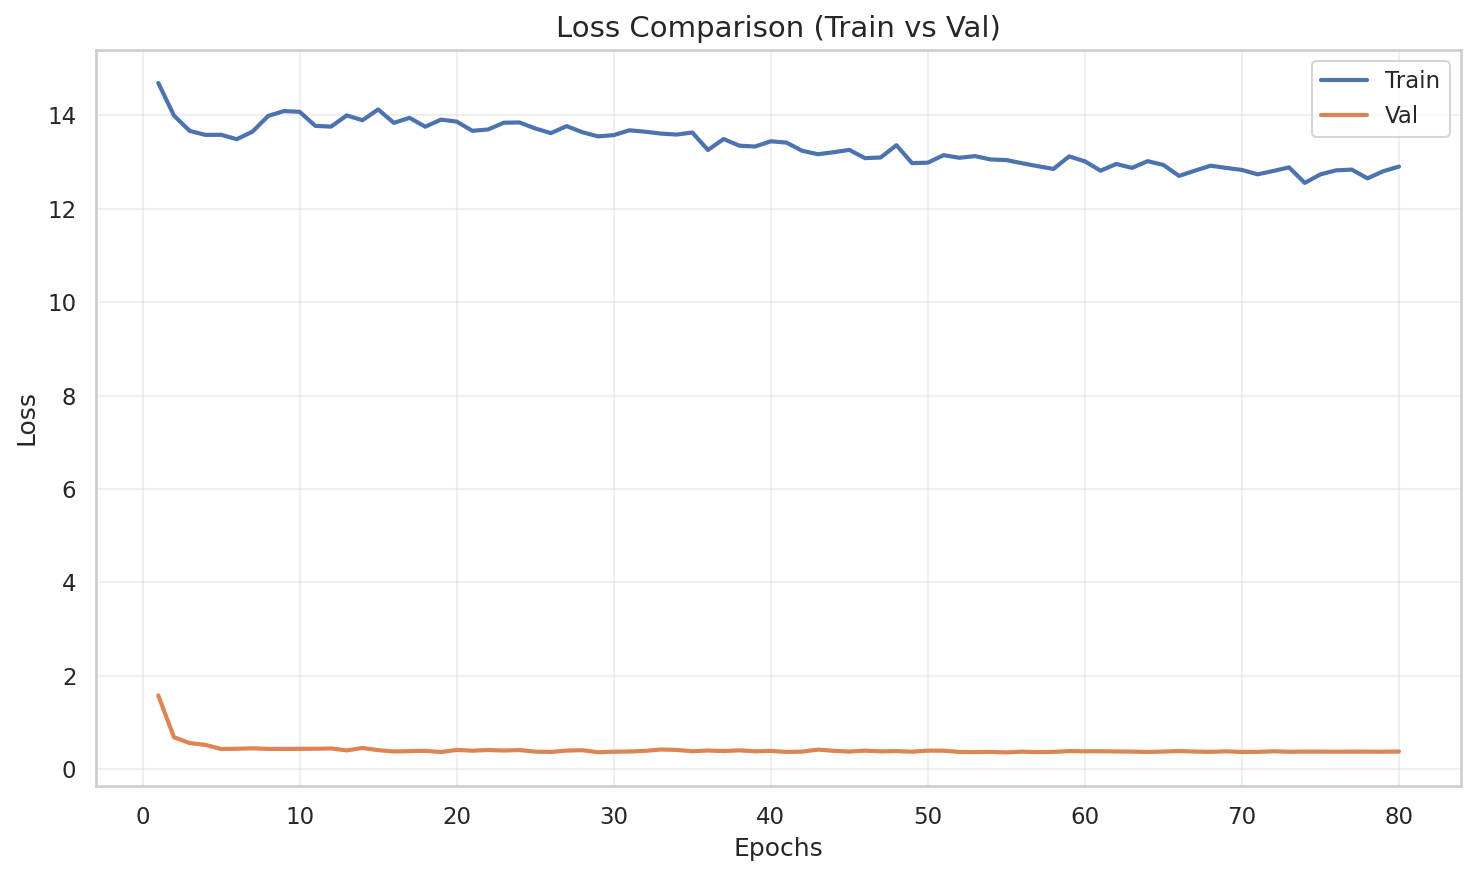

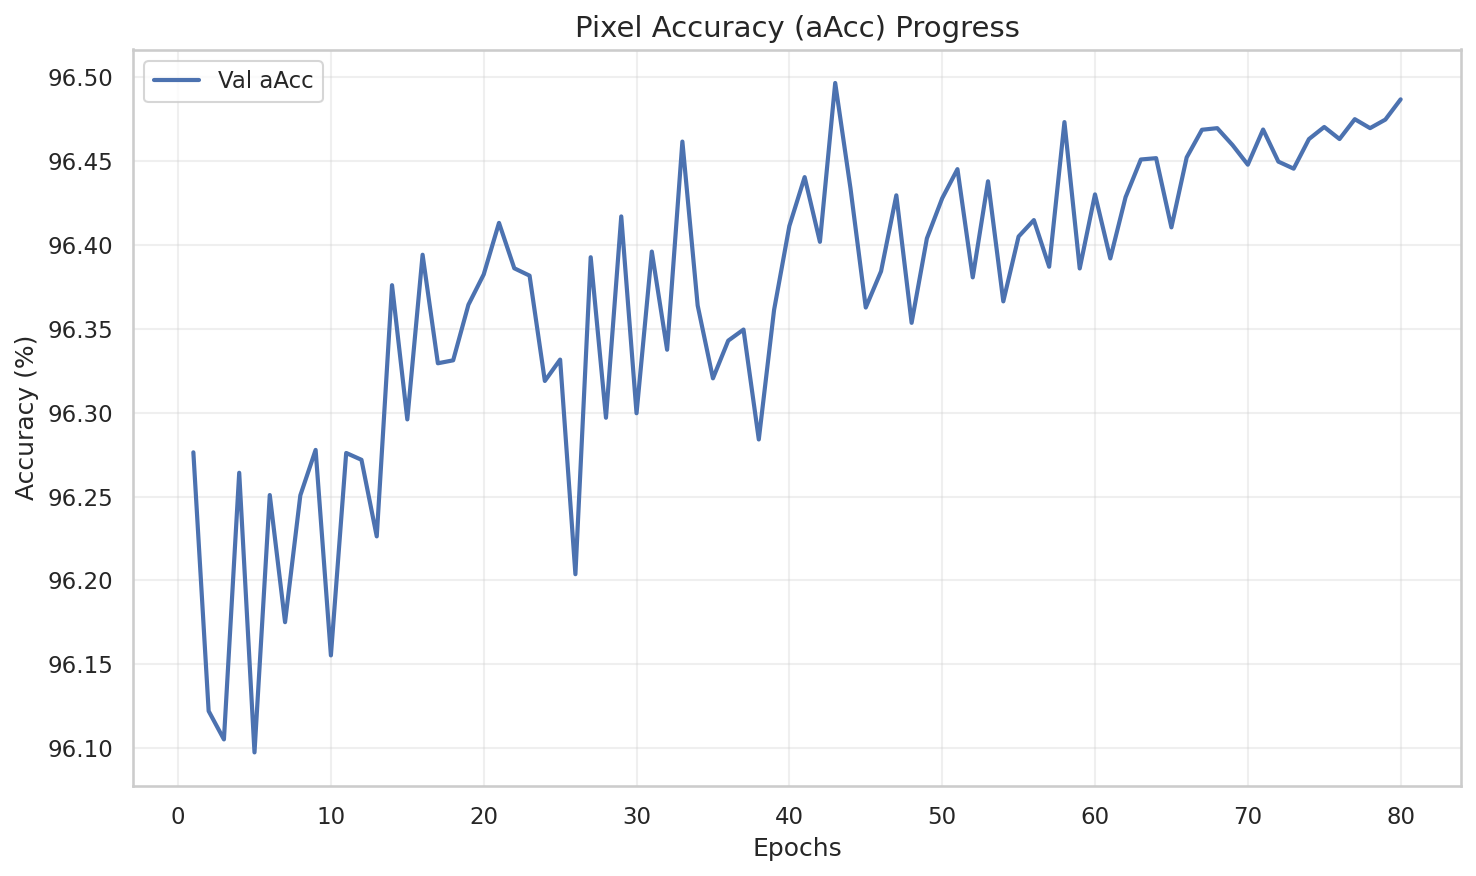

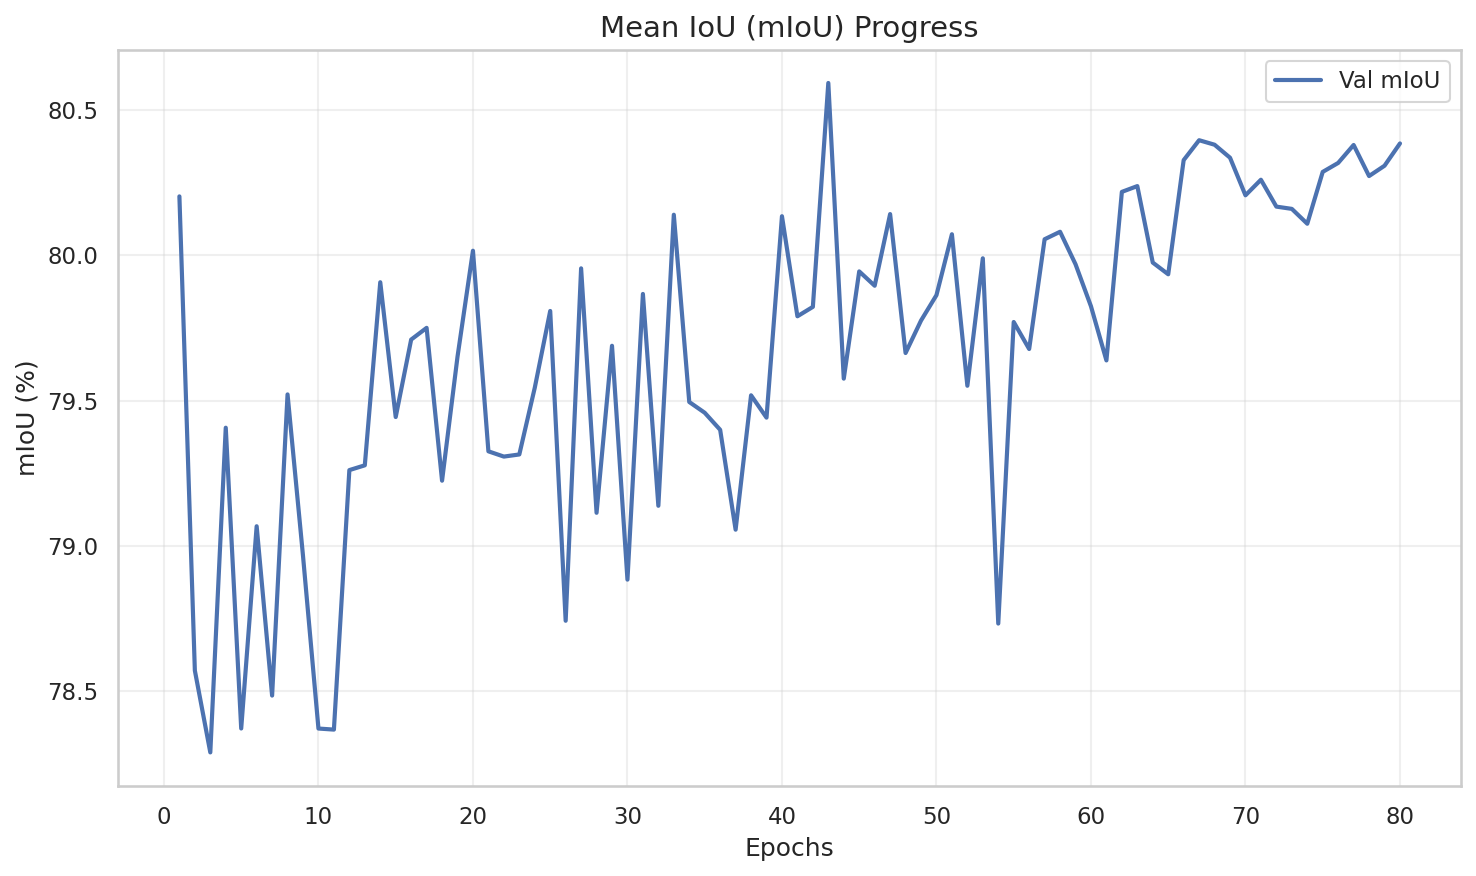

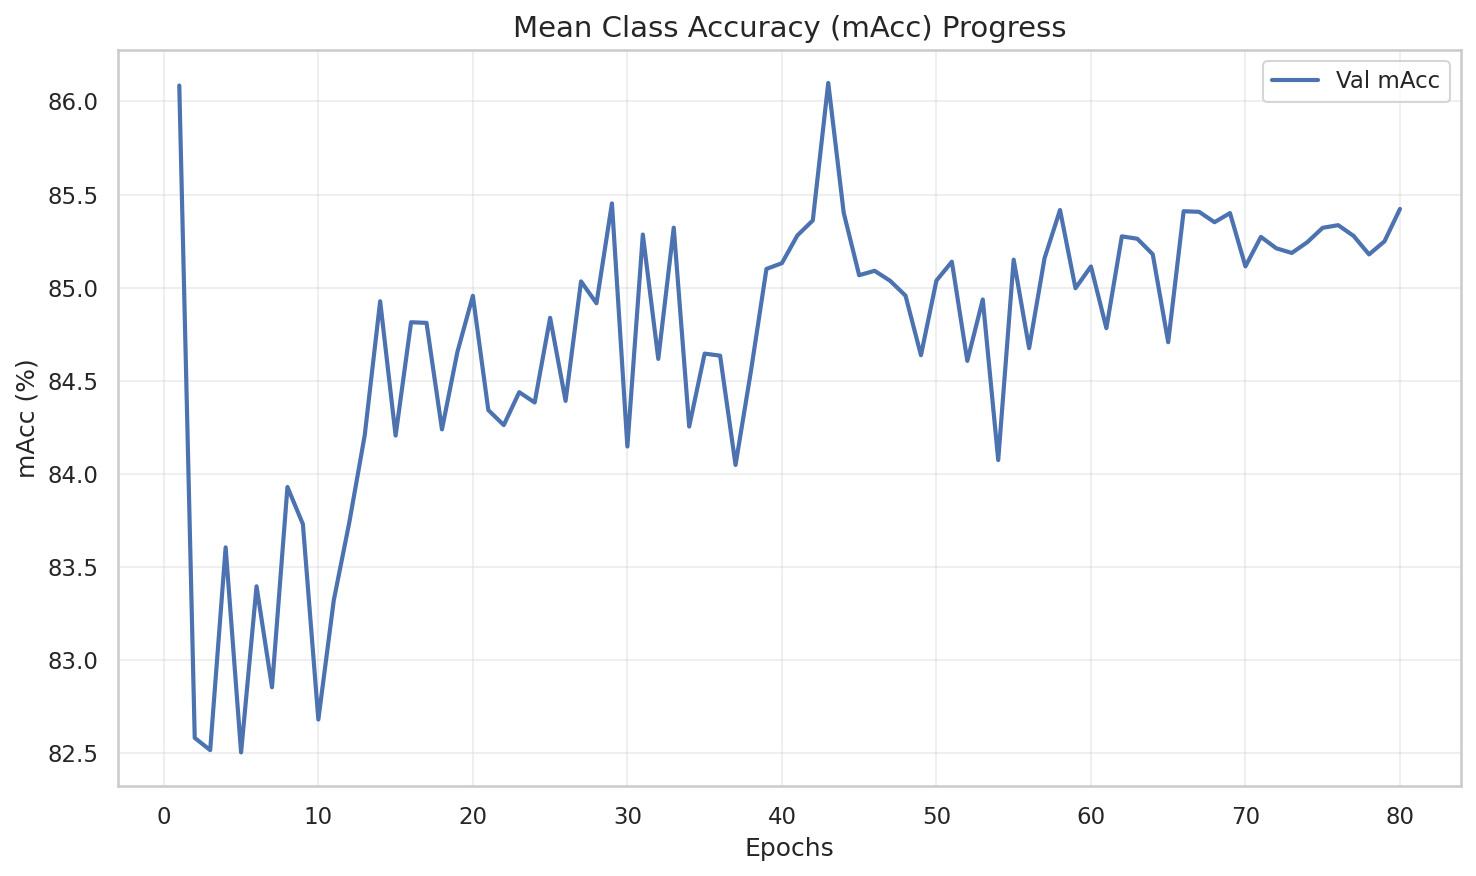

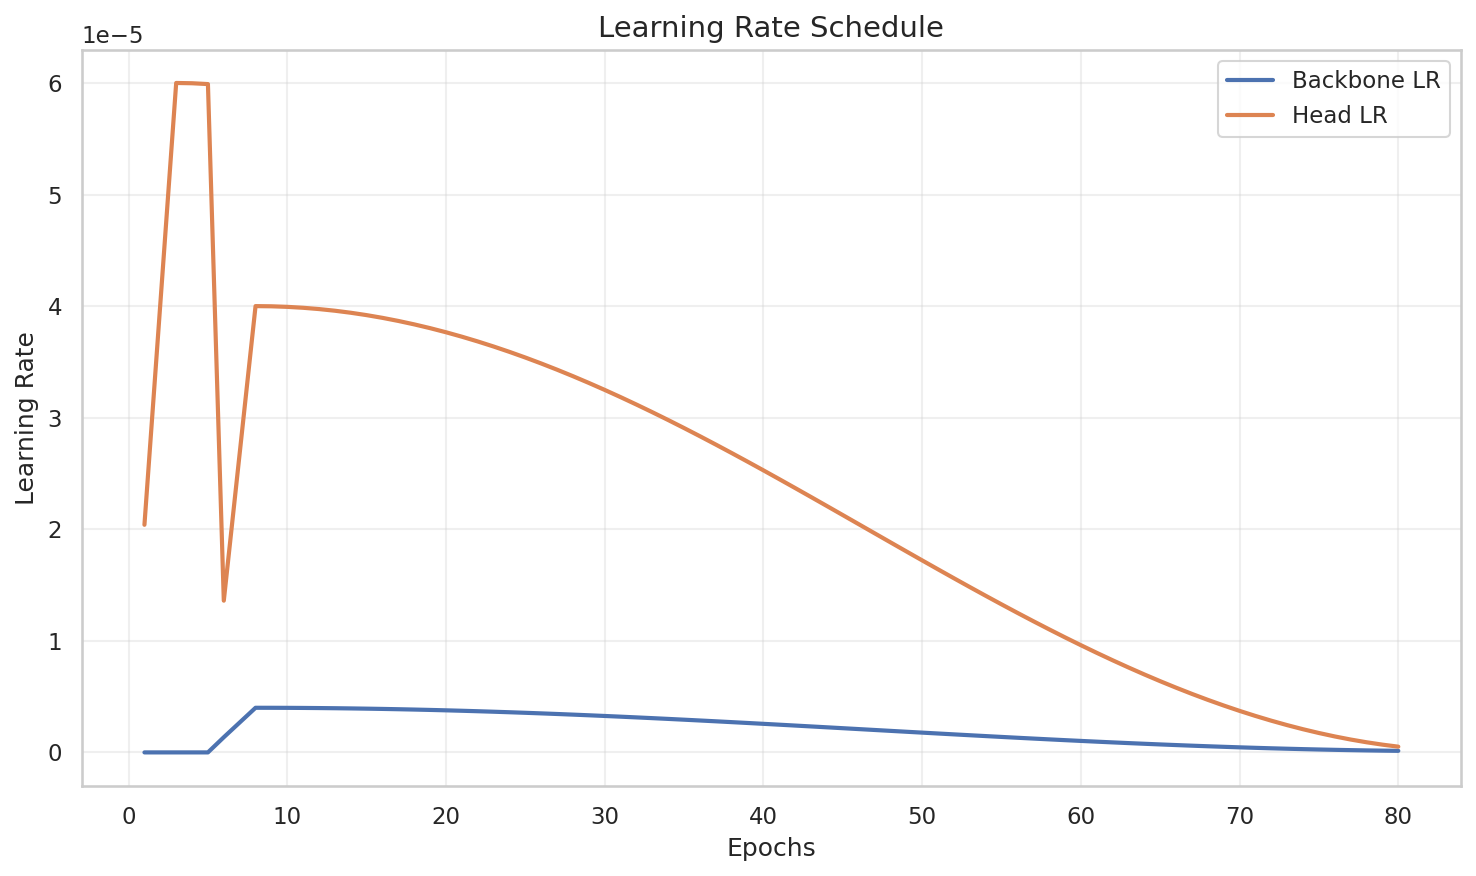

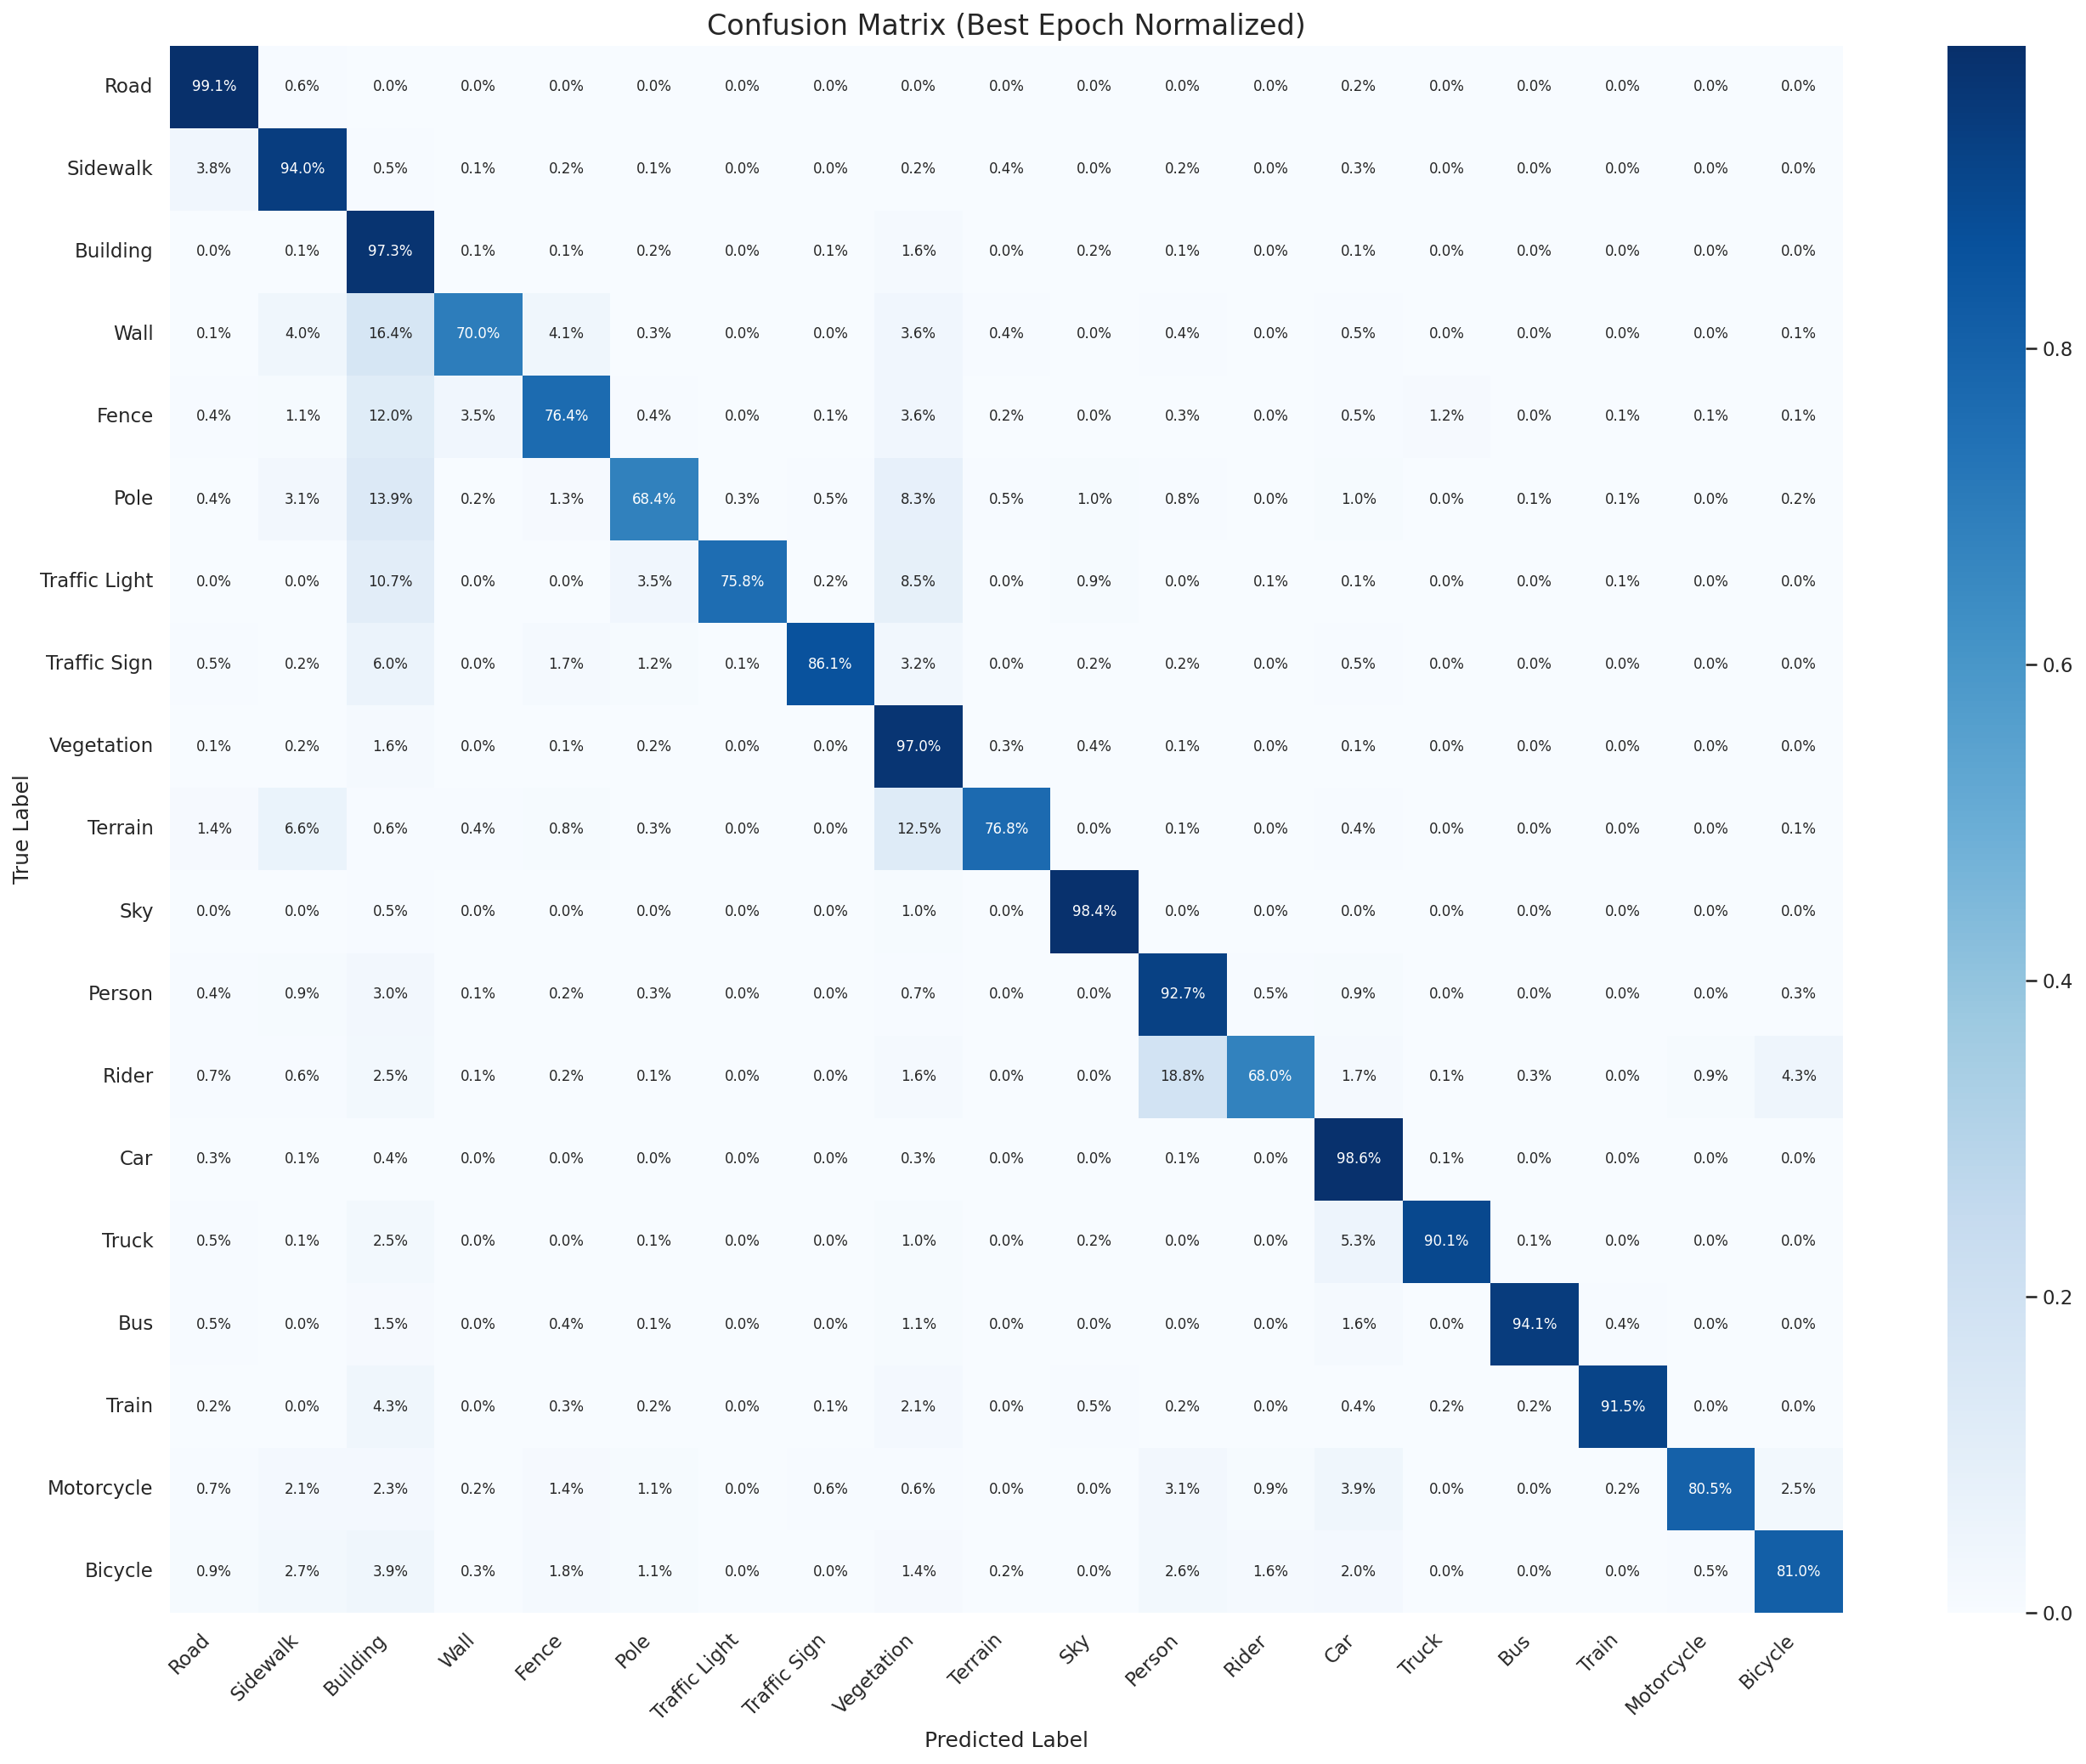


--------------------------------------------------
Model: Swin-Small + Mask2Former
Total Parameters:      68,723,870  (68.72 M)
Trainable Parameters:  67,236,380  (67.24 M)
--------------------------------------------------
SUCCESS: All results saved in: /home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce-Copy1/Results_Export

FINAL RESULTS (Backbone: Swin-Small)
Global Pixel Accuracy (aAcc):   96.49%
Mean IoU (mIoU):                80.38%
Mean Class Accuracy (mAcc):     85.42%
------------------------------------------------------------
CLASS NAME           | IoU (%)    | Accuracy (%)
------------------------------------------------------------
Road                 | 98.39      | 99.13     
Sidewalk             | 86.87      | 94.02     
Building             | 93.30      | 97.29     
Wall                 | 63.26      | 70.05     
Fence                | 65.24      | 76.40     
Pole                 | 63.50      | 68.43     
Traffic Light        | 71.06      | 75.80     
Traffic Si

In [13]:
# ============================================================
# STEP 6: EXPORT RESULTS, PLOTS, CONFUSION MATRIX, FINAL SUMMARY
# For: Mask2Former + Swin-Small
# Revised for: Separate Standard Plots, Detailed Confusion Matrix, and Robust Extraction
# ============================================================

import os
import json
from pathlib import Path
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
required_globals = [
    "history", "model", "CLASS_NAMES", "CLASSES",
    "CHECKPOINT_DIR", "best_record"
]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"Missing required variables from previous steps: {missing}")

BEST_METRICS = globals().get("BEST_METRICS", None)
BEST_CONF_MATRIX = globals().get("BEST_CONF_MATRIX", None)

# ------------------------------------------------------------
# CUSTOM FINAL EXPORT DIRECTORY
# ------------------------------------------------------------
FINAL_SAVE_DIR = "/home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce-Copy1/Results_Export"
FINAL_SAVE_DIR = Path(FINAL_SAVE_DIR)
FINAL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Final export directory: {FINAL_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# BUILD MAIN DATAFRAME (100% Bulletproof Length Matching)
# ------------------------------------------------------------
num_epochs = len(history["epoch"])

def get_hist_col(key, fallback_key=None):
    """Safely extracts a column, ensuring its length perfectly matches num_epochs."""
    col = history.get(key, [])
    if len(col) == num_epochs: return col
    if fallback_key and len(history.get(fallback_key, [])) == num_epochs: return history[fallback_key]
    if len(col) > 0:
        return col + [np.nan] * (num_epochs - len(col)) if len(col) < num_epochs else col[:num_epochs]
    return [np.nan] * num_epochs

df = pd.DataFrame({
    "Epoch": get_hist_col("epoch"),
    "Phase": get_hist_col("phase"),
    "Train_Total_Loss": get_hist_col("train_total_loss"),
    "Train_Native_Loss": get_hist_col("train_native_loss"),
    "Train_CE_Loss": get_hist_col("train_ce_loss"),
    "Train_Lovasz_Loss": get_hist_col("train_lovasz_loss"),
    "Train_Boundary_Loss": get_hist_col("train_boundary_loss"),
    "Train_aAcc": get_hist_col("train_aacc"),
    "Train_mIoU": get_hist_col("train_miou"),
    "Val_Total_Loss": get_hist_col("val_total_loss", fallback_key="val_ce_loss"),
    "Val_CE_Loss": get_hist_col("val_ce_loss"),
    "Val_mIoU": get_hist_col("val_miou"),
    "Val_mAcc": get_hist_col("val_macc"),
    "Val_aAcc": get_hist_col("val_aacc"),
    "LR_Backbone": get_hist_col("backbone_lr"),
    "LR_Head": get_hist_col("head_lr"),
    "Epoch_Time_sec": get_hist_col("epoch_time_sec"),
})

total_training_time_sec = float(df["Epoch_Time_sec"].sum()) if not df["Epoch_Time_sec"].isna().all() else 0.0
df["Total_Training_Session_Time"] = str(timedelta(seconds=int(total_training_time_sec)))

# ------------------------------------------------------------
# PREPARE CLASS-WISE DATA
# ------------------------------------------------------------
class_wise_data = []
if BEST_METRICS is not None:
    for i, name in enumerate(CLASS_NAMES):
        class_wise_data.append({
            "Class Name": name,
            "IoU (%)": BEST_METRICS["iou_per_class"][i] * 100,
            "Accuracy (%)": BEST_METRICS["acc_per_class"][i] * 100
        })

# ------------------------------------------------------------
# EXPORT FINAL RESULTS CSV & EXCEL
# ------------------------------------------------------------
final_v_acc = df["Val_aAcc"].iloc[-1] * 100 if not np.isnan(df["Val_aAcc"].iloc[-1]) else 0.0
final_mIoU = df["Val_mIoU"].iloc[-1] * 100 if not np.isnan(df["Val_mIoU"].iloc[-1]) else 0.0
final_mAcc = df["Val_mAcc"].iloc[-1] * 100 if not np.isnan(df["Val_mAcc"].iloc[-1]) else 0.0

final_global_data = [
    {"Metric": "Global Pixel Accuracy (aAcc)", "Value": f"{final_v_acc:.2f}%"},
    {"Metric": "Mean IoU (mIoU)", "Value": f"{final_mIoU:.2f}%"},
    {"Metric": "Mean Class Accuracy (mAcc)", "Value": f"{final_mAcc:.2f}%"}
]
pd.DataFrame(final_global_data).to_csv(FINAL_SAVE_DIR / "finalresults.csv", index=False)

excel_path = FINAL_SAVE_DIR / "Training_Metrics_Report.xlsx"
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Epoch_Metrics', index=False)
    if class_wise_data:
        pd.DataFrame(class_wise_data).to_excel(writer, sheet_name='Class_Wise_Results', index=False)

# ------------------------------------------------------------
# STANDARD SEPARATE PLOTS
# ------------------------------------------------------------
sns.set_style("whitegrid")

def save_separate_plot(filename, title, ylabel, train_data, val_data=None, label1="Train", label2="Val"):
    plt.figure(figsize=(10, 6))
    
    # Filter out NaNs
    train_clean = np.array(train_data, dtype=float)
    plt.plot(range(1, len(train_clean)+1), train_clean, label=label1, lw=2)
    
    if val_data is not None:
        val_clean = np.array(val_data, dtype=float)
        if not np.isnan(val_clean).all():
            plt.plot(range(1, len(val_clean)+1), val_clean, label=label2, lw=2)
            
    plt.title(title, fontsize=14)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FINAL_SAVE_DIR / f"{filename}.png", dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()

# Extract data for plotting
train_loss = df["Train_Total_Loss"].tolist()
val_loss = df["Val_CE_Loss"].tolist()

# Multiply accuracies by 100 for percentages
train_aacc = (df["Train_aAcc"] * 100).tolist() if not df["Train_aAcc"].isna().all() else None
val_aacc = (df["Val_aAcc"] * 100).tolist()
val_miou = (df["Val_mIoU"] * 100).tolist()
val_macc = (df["Val_mAcc"] * 100).tolist()
lr_backbone = df["LR_Backbone"].tolist()
lr_head = df["LR_Head"].tolist()

# 1. Loss Plot
save_separate_plot("loss_comparison", "Loss Comparison (Train vs Val)", "Loss", train_loss, val_loss)

# 2. Pixel Accuracy Plot
if train_aacc is not None:
    save_separate_plot("accuracy_comparison", "Pixel Accuracy (aAcc) Comparison", "Accuracy (%)", train_aacc, val_aacc)
else:
    save_separate_plot("accuracy_comparison", "Pixel Accuracy (aAcc) Progress", "Accuracy (%)", val_aacc, label1="Val aAcc")

# 3. mIoU Plot
save_separate_plot("miou_progress", "Mean IoU (mIoU) Progress", "mIoU (%)", val_miou, label1="Val mIoU")

# 4. mAcc Plot
save_separate_plot("macc_progress", "Mean Class Accuracy (mAcc) Progress", "mAcc (%)", val_macc, label1="Val mAcc")

# 5. Learning Rate Plot
save_separate_plot(
    "learning_rate_progress", "Learning Rate Schedule", "Learning Rate", 
    lr_backbone, lr_head, label1="Backbone LR", label2="Head LR"
)

# ------------------------------------------------------------
# PERCENTAGE-BASED CONFUSION MATRIX
# ------------------------------------------------------------
if BEST_CONF_MATRIX is not None:
    # Increased figsize to accommodate 19 classes with text
    plt.figure(figsize=(18, 14)) 
    
    # Normalize by row (True Label) to get percentages
    cm_normalized = BEST_CONF_MATRIX.astype('float') / (BEST_CONF_MATRIX.sum(axis=1)[:, np.newaxis] + 1e-10)
    
    # annot=True and fmt='.1%' display percentages directly
    sns.heatmap(
        cm_normalized, annot=True, fmt='.1%', cmap='Blues', 
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, 
        annot_kws={"size": 8} # Slightly smaller font to fit the 19x19 grid
    ) 
    
    plt.title("Confusion Matrix (Best Epoch Normalized)", fontsize=16)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(FINAL_SAVE_DIR / "confusion_matrix.png", dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()

# ------------------------------------------------------------
# PARAMETER COUNT & FINAL PRINT SUMMARY
# ------------------------------------------------------------
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n--------------------------------------------------")
print(f"Model: Swin-Small + Mask2Former")
print(f"Total Parameters:      {total_params:,}  ({total_params/1e6:.2f} M)")
print(f"Trainable Parameters:  {trainable_params:,}  ({trainable_params/1e6:.2f} M)")
print(f"--------------------------------------------------")
print(f"SUCCESS: All results saved in: {FINAL_SAVE_DIR}")
print("\n" + "="*60)
print(f"FINAL RESULTS (Backbone: Swin-Small)")
print("="*60)
print(f"Global Pixel Accuracy (aAcc):   {final_v_acc:.2f}%")
print(f"Mean IoU (mIoU):                {final_mIoU:.2f}%")
print(f"Mean Class Accuracy (mAcc):     {final_mAcc:.2f}%")
print("-" * 60)
print(f"{'CLASS NAME':<20} | {'IoU (%)':<10} | {'Accuracy (%)':<10}")
print("-" * 60)

if class_wise_data:
    for item in class_wise_data:
        print(f"{item['Class Name']:<20} | {item['IoU (%)']:<10.2f} | {item['Accuracy (%)']:<10.2f}")

Graph saved successfully to:
/home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce-Copy1/Results_Export/combined_metrics_filtered_progress.png


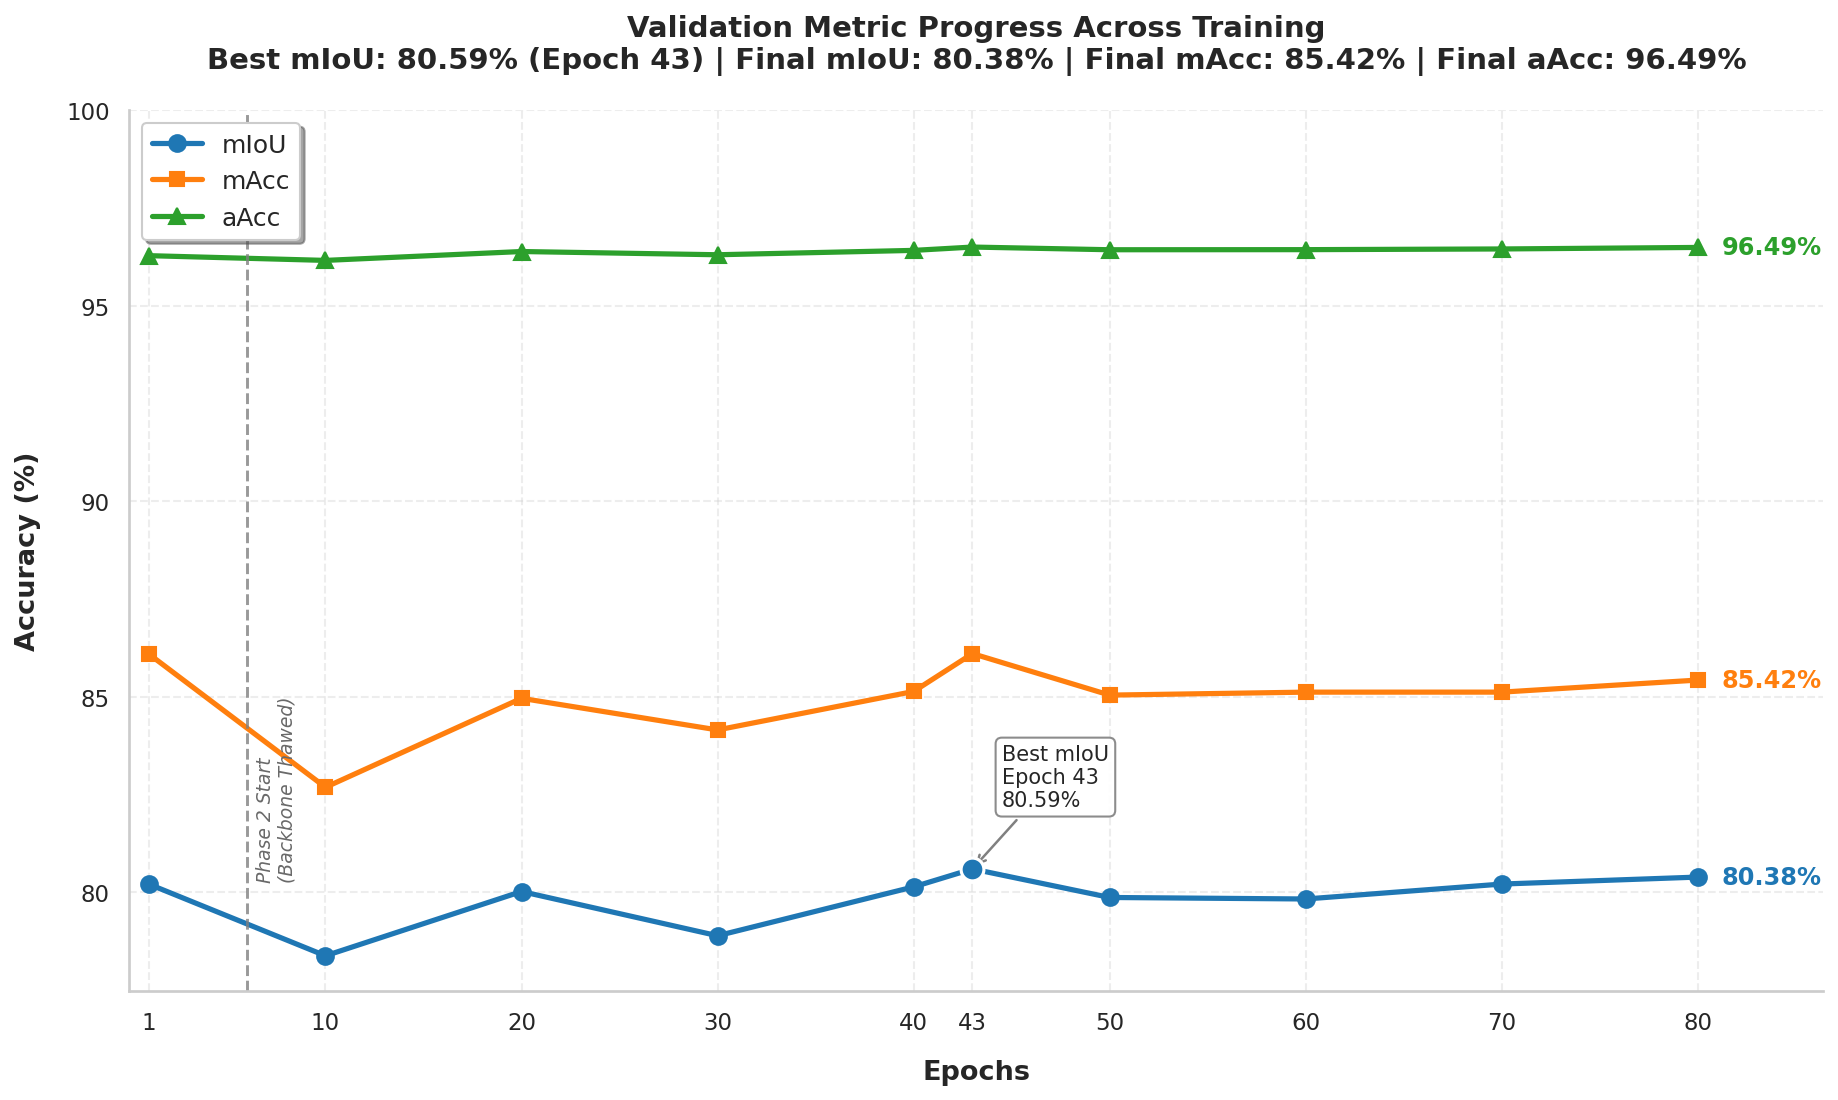

In [12]:
# ============================================================
# STEP 7: PRESENTATION-READY MULTI-METRIC PROGRESS GRAPH
# For: Mask2Former + Swin-Small
# Revised for: End-of-line annotations, Upper-Left Legend, Original Colors
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# SAFETY CHECKS & DIRECTORY SETUP
# ------------------------------------------------------------
required_globals = ["history"]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"Missing required variables from previous steps: {missing}")

if "val_miou" not in history or len(history["val_miou"]) == 0:
    raise ValueError("history['val_miou'] is empty. Run training (Step 5) before Step 7.")

FINAL_SAVE_DIR = Path(globals().get("FINAL_SAVE_DIR", "./Results_Export"))
FINAL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# PREPARE EPOCHS & DATA
# ------------------------------------------------------------
all_epochs = history["epoch"]
best_epoch = globals().get("best_record", {}).get("best_epoch", all_epochs[-1])

# Filter epochs to reduce visual clutter: Epoch 1, every 10th epoch, best epoch, final epoch
filtered_epochs_set = set([e for e in all_epochs if e == 1 or e % 10 == 0] + [all_epochs[-1], best_epoch])
filtered_epochs = sorted(list(filtered_epochs_set))

indices = [all_epochs.index(e) for e in filtered_epochs]

# Extract and convert to percentages
miou_scores = [history["val_miou"][i] * 100.0 for i in indices]
macc_scores = [history["val_macc"][i] * 100.0 for i in indices]
aacc_scores = [history["val_aacc"][i] * 100.0 for i in indices]

best_miou = max(history["val_miou"]) * 100.0
best_miou_epoch = history["val_miou"].index(max(history["val_miou"])) + 1

final_miou = history["val_miou"][-1] * 100.0
final_macc = history["val_macc"][-1] * 100.0
final_aacc = history["val_aacc"][-1] * 100.0
final_x = all_epochs[-1]

# ------------------------------------------------------------
# PLOT SETUP (Restoring original colors)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12.5, 7.5)) 

color_miou = '#1f77b4'  # Blue
color_macc = '#ff7f0e'  # Orange
color_aacc = '#2ca02c'  # Green

ax.plot(filtered_epochs, miou_scores, marker='o', linewidth=2.5, markersize=8, label='mIoU', color=color_miou)
ax.plot(filtered_epochs, macc_scores, marker='s', linewidth=2.5, markersize=7, label='mAcc', color=color_macc)
ax.plot(filtered_epochs, aacc_scores, marker='^', linewidth=2.5, markersize=8, label='aAcc', color=color_aacc)

# ------------------------------------------------------------
# AXIS LABELS
# ------------------------------------------------------------
ax.set_xlabel('Epochs', fontsize=13, fontweight='bold', labelpad=12)
ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold', labelpad=12)
ax.set_xticks(filtered_epochs)

# ------------------------------------------------------------
# DYNAMIC PHASE TRANSITION ANNOTATIONS
# ------------------------------------------------------------
y_min, y_max = ax.get_ylim()
phase_text_y = y_min + (y_max - y_min) * 0.14

phase_changes = []
if "phase" in history and len(history["phase"]) > 0:
    prev_phase = history["phase"][0]
    for i, ph in enumerate(history["phase"]):
        if ph != prev_phase:
            phase_changes.append((all_epochs[i], ph))
            prev_phase = ph

for change_epoch, new_phase in phase_changes:
    ax.axvline(x=change_epoch, color='gray', linestyle='--', alpha=0.8, linewidth=1.4)
    ax.text(
        change_epoch + 0.45, phase_text_y,
        f'Phase {new_phase} Start\n(Backbone Thawed)',
        rotation=90, va='bottom', ha='left',
        fontsize=9, color='dimgray', fontstyle='italic'
    )

# ------------------------------------------------------------
# BEST mIoU ANNOTATION 
# ------------------------------------------------------------
ax.scatter(best_miou_epoch, best_miou, s=120, zorder=5, color=color_miou, edgecolors='white', linewidth=1.5)

if best_miou_epoch <= (max(filtered_epochs) * 0.6):
    best_text_x = best_miou_epoch + 1.5
    best_ha = "left"
else:
    best_text_x = best_miou_epoch - 1.5
    best_ha = "right"

ax.annotate(
    f'Best mIoU\nEpoch {best_miou_epoch}\n{best_miou:.2f}%',
    xy=(best_miou_epoch, best_miou),
    xytext=(best_text_x, best_miou + 1.5),
    fontsize=10, ha=best_ha, va='bottom',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
    arrowprops=dict(arrowstyle='->', color='gray', lw=1.2)
)

# ------------------------------------------------------------
# END-OF-LINE FINAL VALUE ANNOTATIONS (Clean & No Overlap)
# ------------------------------------------------------------
# Placed directly to the right of the final points. 
# Because 96%, 84%, and 79% are far apart vertically, they will not overlap.
offset_x = max(all_epochs) * 0.015  # Dynamic spacing based on total epochs

ax.text(final_x + offset_x, final_miou, f'{final_miou:.2f}%', va='center', ha='left', fontsize=11.5, fontweight='bold', color=color_miou)
ax.text(final_x + offset_x, final_macc, f'{final_macc:.2f}%', va='center', ha='left', fontsize=11.5, fontweight='bold', color=color_macc)
ax.text(final_x + offset_x, final_aacc, f'{final_aacc:.2f}%', va='center', ha='left', fontsize=11.5, fontweight='bold', color=color_aacc)

# Expand the right side of the graph so the text fits perfectly inside the image
ax.set_xlim(left=0, right=max(all_epochs) + (max(all_epochs) * 0.08))
ax.set_ylim(top=100) 

# ------------------------------------------------------------
# STYLING & LEGEND
# ------------------------------------------------------------
ax.legend(loc='upper left', fontsize=12, frameon=True, fancybox=True, shadow=True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.3)
ax.spines['left'].set_linewidth(1.3)

ax.grid(True, linestyle='--', alpha=0.35)

title_main = "Validation Metric Progress Across Training"
title_sub = f"Best mIoU: {best_miou:.2f}% (Epoch {best_miou_epoch}) | Final mIoU: {final_miou:.2f}% | Final mAcc: {final_macc:.2f}% | Final aAcc: {final_aacc:.2f}%"

ax.set_title(
    title_main + "\n" + title_sub,
    fontsize=14, fontweight='bold', pad=20
)

plt.tight_layout()

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
combined_graph_path = os.path.join(FINAL_SAVE_DIR, "combined_metrics_filtered_progress.png")
plt.savefig(combined_graph_path, dpi=600, bbox_inches='tight')
print(f"Graph saved successfully to:\n{combined_graph_path}")

plt.show()
plt.close()